# ASSIGNMENT 06: RECURRENT NEURAL NETWORKS (RNN)
## Notebook 03: Dự Đoán Giá Cổ Phiếu S&P 500 Bằng TensorFlow / Keras Vanilla RNN
### Tích Hợp Toàn Diện: Tiền Xử Lý Chuỗi Thời Gian, Xây Dựng Mô Hình Keras Sequential, Huấn Luyện, Đánh Giá & So Sánh Kỹ Thuật PyTorch vs Keras

---

### Mục tiêu tổng thể của Notebook 03:
Notebook này cung cấp một quy trình học sâu hoàn chỉnh (End-to-End Deep Learning Pipeline) chuẩn mực khoa học nhằm giải quyết bài toán dự báo chuỗi thời gian tài chính sử dụng mạng nơ-ron hồi quy **Vanilla RNN** xây dựng bằng **TensorFlow / Keras**:

* **PHẦN 1: Khám Phá Dữ Liệu & Tiền Xử Lý Chuỗi Thời Gian (Data Pipeline)**:
  1. Đọc trực tiếp nguồn dữ liệu thực tế S&P 500 (`all_stocks_5yr.csv`), không sử dụng dữ liệu tự sinh.
  2. Phân tích chi tiết cấu trúc dataset: kích thước (dimensions), tên cột, kiểu dữ liệu, missing values, duplicates, date range, số lượng thực thể (stocks).
  3. Khám phá & Trực quan hóa dữ liệu (EDA): Phân bố giá đóng cửa, xu hướng biến động theo thời gian kèm đường trung bình động (SMA 20, 50, 200 ngày), khối lượng giao dịch (volume) và so sánh chéo đa mã công nghệ hàng đầu. Từng biểu đồ đều có giải thích chuyên sâu: *"Dữ liệu này phân bố như vậy có ý nghĩa gì?"*.
  4. Thiết kế bài toán chuỗi thời gian: Lựa chọn mã cổ phiếu đại diện (`AAPL`), chỉ định Target (`close` tại $t+1$) và bộ 5 đặc trưng đa biến (OHLCV) với lý do rõ ràng.
  5. Phân chia dữ liệu theo trục thời gian (Chronological Split: 70% Train, 15% Val, 15% Test) chống rò rỉ dữ liệu (Data Leakage).
  6. Chuẩn hóa dữ liệu bằng `MinMaxScaler(0, 1)`, tuân thủ nguyên tắc fit nghiêm ngặt chỉ trên tập Train.
  7. Tạo cấu trúc cửa sổ trượt (Sliding Windows $L = 20$).
  8. Chuyển đổi dữ liệu sang định dạng TensorFlow / Keras (NumPy 3D mảng `np.float32` và pipeline `tf.data.Dataset`).
  9. In rõ ràng kích thước các mảng: `X_train.shape`, `y_train.shape`, `X_val.shape`, `y_val.shape`, `X_test.shape`, `y_test.shape`.
  10. Bảng tổng kết thông số kỹ thuật `Ready for Keras RNN`.

* **PHẦN 2: Xây Dựng, Huấn Luyện & Đánh Giá Mô Hình Keras RNN**:
  11. Xây dựng kiến trúc mô hình Vanilla RNN bằng `tf.keras.Sequential` với `tf.keras.layers.SimpleRNN` và `tf.keras.layers.Dense` (không sử dụng LSTM/GRU), tương đương về mặt toán học với notebook PyTorch.
  12. Cấu hình compile mô hình: Giải thích chi tiết lý do lựa chọn bộ tối ưu Adam và hàm mất mát MSE.
  13. Huấn luyện mô hình bằng `model.fit()`: Cấu hình `validation_data`, epochs, batch_size, đảm bảo không shuffle time series gây leakage, tích hợp callback `EarlyStopping`.
  14. Trực quan hóa đường cong học tập (Learning Curve): Vẽ biểu đồ Training Loss vs Validation Loss trên cả thang đo tuyến tính và logarit; phân tích hiện tượng Overfitting.
  15. Thực hiện dự đoán trên Test Set bằng `model.predict()` và khôi phục thang đo giá gốc USD bằng `inverse_transform`.
  16. Đánh giá đa chiều với bộ chỉ số định lượng: MAE, MSE, RMSE, MAPE.
  17. Trực quan hóa so sánh Thực tế vs Dự đoán (Actual vs Predicted) và biểu đồ phần dư (Residuals).
  18. Phân tích chuyên sâu: Năng lực dự báo xu hướng, hiện tượng trễ pha 1 bước (Phase lag), bản chất của thị trường tài chính (Low SNR, Efficient Market Hypothesis - EMH) và giới hạn của Vanilla RNN.
  19. So sánh kỹ thuật toàn diện `PyTorch vs Keras implementation` qua 6 khía cạnh: model definition, training loop, optimizer, loss, prediction, evaluation (mô tả kỹ thuật thuần túy, không xếp hạng).
  20. Tổng kết toàn diện (`Conclusion`).

---

### Bảng Mục Lục Điều Hướng:
#### PHẦN 1: EDA, TIỀN XỬ LÝ & CHUẨN BỊ TENSOR KERAS
1. [Xác Định & Tải Dataset Thực Tế](#section-1)
2. [Phân Tích Chi Tiết Cấu Trúc Toàn Diện Dataset](#section-2)
3. [Trích Xuất Mã Tiêu Biểu (AAPL) & Phân Tích Thống Kê Sâu (Target, Temporal, Outliers)](#section-3)
4. [Trực Quan Hóa Dữ Liệu (EDA) & Giải Thích Ý Nghĩa Thực Tiễn](#section-4)
5. [Thiết Kế Bài Toán RNN & Lựa Chọn Target / Features Có Rationale Rõ Ràng](#section-5)
6. [Phân Chia Train / Validation / Test Theo Trục Thời Gian (Chronological Split)](#section-6)
7. [Chuẩn Hóa Dữ Liệu (Scaling) & Phòng Chống Rò Rỉ Dữ Liệu (Data Leakage)](#section-7)
8. [Tạo Cấu Trúc Cửa Sổ Trượt (Sliding Windows) Cho RNN](#section-8)
9. [Chuyển Đổi Dữ Liệu Thành Định Dạng Tương Thích TensorFlow / Keras](#section-9)
10. [Ready for Keras RNN (Bảng Tổng Kết Thông Số)](#section-10)

#### PHẦN 2: XÂY DỰNG, HUẤN LUYỆN, ĐÁNH GIÁ & SO SÁNH PYTORCH VS KERAS
11. [Xây Dựng Mô Hình Keras Sequential Vanilla RNN](#section-11)
12. [Cấu Hình Compile Mô Hình (Optimizer Adam & Loss MSE)](#section-12)
13. [Huấn Luyện Mô Hình Với model.fit() & Callbacks](#section-13)
14. [Đường Cong Học Tập (Learning Curve - Loss Curve Analysis)](#section-14)
15. [Thực Hiện Dự Đoán (Prediction) & Khôi Phục Thang Đo Gốc (Inverse Transform)](#section-15)
16. [Đo Lường Định Lượng Hiệu Năng (Evaluation Metrics: MAE, MSE, RMSE, MAPE)](#section-16)
17. [Trực Quan Hóa Kết Quả Dự Đoán (Actual vs Predicted & Residuals)](#section-17)
18. [Phân Tích Chuyên Sâu Kết Quả & Giới Hạn Của RNN Trong Tài Chính](#section-18)
19. [PyTorch vs Keras Implementation (So Sánh Kỹ Thuật Toàn Diện)](#section-19)
20. [Conclusion (Tổng Kết Cuối Cùng)](#section-20)


---
<a id="section-1"></a>
## 1. Xác Định & Tải Dataset Thực Tế

### 1.1. Nguồn Dữ Liệu & Vị Trí Lưu Trữ:
* Bộ dữ liệu được lưu trữ trực tiếp trong thư mục dự án: `dataset/all_stocks_5yr.csv`.
* **Nguồn gốc**: Bộ dữ liệu chuẩn mực Kaggle - *S&P 500 Stock Data* (tác giả Cam Nugent). [Link Kaggle Dataset](https://www.kaggle.com/datasets/camnugent/sandp500).
* **Tính chất**: Dữ liệu chứa thông tin giao dịch hàng ngày của các công ty niêm yết trong chỉ số S&P 500 của thị trường chứng khoán Mỹ qua giai đoạn 5 năm liên tục (2013 – 2018).
* **Cam kết**: Đọc trực tiếp từ file CSV nguyên bản, không sử dụng dữ liệu tự sinh hay bất kỳ nguồn dữ liệu giả lập nào.


In [1]:
# 1. Kiểm tra file và đọc dataset thực tế bằng Pandas
import os
import pandas as pd
import numpy as np

from pathlib import Path
dataset_candidates = [Path("dataset/all_stocks_5yr.csv"), Path("Assignment 06/dataset/all_stocks_5yr.csv"), Path("../dataset/all_stocks_5yr.csv")]
dataset_path = next((p for p in dataset_candidates if p.is_file()), dataset_candidates[0])

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Lỗi: Không tìm thấy file dữ liệu tại đường dẫn '{dataset_path}'!")

file_size_mb = os.path.getsize(dataset_path) / (1024 * 1024)
print(f"-> Xác thực thành công: File dataset tồn tại tại '{dataset_path}'")
print(f"-> Dung lượng tập tin: {file_size_mb:.2f} MB")

# Đọc toàn bộ dữ liệu vào Pandas DataFrame
df_raw = pd.read_csv(dataset_path)
print(f"-> Nạp dữ liệu hoàn tất! Tổng số mẫu: {df_raw.shape[0]:,} dòng | Số thuộc tính: {df_raw.shape[1]} cột.")


-> Xác thực thành công: File dataset tồn tại tại 'dataset\all_stocks_5yr.csv'
-> Dung lượng tập tin: 28.21 MB


-> Nạp dữ liệu hoàn tất! Tổng số mẫu: 619,040 dòng | Số thuộc tính: 7 cột.


---
<a id="section-2"></a>
## 2. Phân Tích Chi Tiết Cấu Trúc Toàn Diện Dataset

Để nắm bắt toàn diện bản chất của tập dữ liệu trước khi xây dựng mô hình học sâu, chúng ta tiến hành khảo sát có hệ thống 7 tiêu chí kỹ thuật cốt lõi:
1. **Dimensions**: Số lượng dòng (samples) và số lượng cột (features).
2. **Columns**: Danh sách tên các cột và ý nghĩa tài chính thực tế của từng cột.
3. **Datatypes**: Kiểu dữ liệu tương ứng của mỗi thuộc tính (text, datetime, floating-point, integer).
4. **Missing Values**: Đếm số lượng và tỉ lệ phần trăm các ô bị thiếu dữ liệu trên từng cột.
5. **Duplicates**: Kiểm tra các bản ghi trùng lặp hoàn toàn (duplicated rows).
6. **Date Range**: Khoảng thời gian ghi nhận (ngày bắt đầu, ngày kết thúc và tổng thời gian).
7. **Number of stocks/entities**: Tổng số lượng mã cổ phiếu riêng biệt có mặt trong bảng và tần suất xuất hiện của các mã phổ biến nhất.


In [2]:
# 2. Khảo sát 7 tiêu chí kỹ thuật toàn diện của dataset

print("================================================================================")
print("1. KÍCH THƯỚC (DIMENSIONS):")
print(f"   -> Số hàng (Rows)   : {df_raw.shape[0]:,}")
print(f"   -> Số cột (Columns) : {df_raw.shape[1]}")

print("\n================================================================================")
print("2 & 3. DANH SÁCH CỘT & KIỂU DỮ LIỆU (COLUMNS & DATATYPES):")
col_info = pd.DataFrame({
    'Cột': df_raw.columns,
    'Kiểu dữ liệu (dtype)': df_raw.dtypes.values,
    'Số lượng Non-Null': df_raw.notnull().sum().values,
    'Mô tả ý nghĩa': [
        'Ngày diễn ra phiên giao dịch (YYYY-MM-DD)',
        'Giá mở cửa phiên giao dịch (USD)',
        'Mức giá cao nhất đạt được trong phiên (USD)',
        'Mức giá thấp nhất chạm tới trong phiên (USD)',
        'Mức giá đóng cửa chốt phiên (USD) - Biến Target cốt lõi',
        'Tổng khối lượng cổ phiếu khớp lệnh trong phiên (cổ phiếu)',
        'Mã niêm yết (Ticker Symbol) của công ty'
    ]
})
display(col_info)

print("\n================================================================================")
print("4. KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES):")
missing_cnt = df_raw.isnull().sum()
missing_pct = (missing_cnt / len(df_raw)) * 100
df_missing = pd.DataFrame({'Missing Count': missing_cnt, 'Missing Ratio (%)': missing_pct})
display(df_missing)

print("\n================================================================================")
print("5. KIỂM TRA BẢN GHI TRÙNG LẶP (DUPLICATES):")
num_duplicates = df_raw.duplicated().sum()
print(f"   -> Tổng số bản ghi trùng lặp hoàn toàn: {num_duplicates} dòng (0.00%). Dữ liệu đạt độ toàn vẹn cao!")

print("\n================================================================================")
print("6. KHOẢNG THỜI GIAN GIAO DỊCH (DATE RANGE):")
min_date = df_raw['date'].min()
max_date = df_raw['date'].max()
print(f"   -> Ngày bắt đầu quan sát : {min_date}")
print(f"   -> Ngày kết thúc quan sát: {max_date}")
print(f"   -> Thời gian bao phủ     : Tròn 5 năm lịch sử giao dịch liên tục (2013 - 2018).")

print("\n================================================================================")
print("7. SỐ LƯỢNG MÃ CỔ PHIẾU / ENTITIES:")
unique_tickers = df_raw['Name'].nunique()
print(f"   -> Tổng số mã cổ phiếu duy nhất: {unique_tickers} mã công ty trong rổ S&P 500.")
print("\nTop 10 mã cổ phiếu có số lượng phiên quan sát đầy đủ nhất:")
print(df_raw['Name'].value_counts().head(10))


1. KÍCH THƯỚC (DIMENSIONS):
   -> Số hàng (Rows)   : 619,040
   -> Số cột (Columns) : 7

2 & 3. DANH SÁCH CỘT & KIỂU DỮ LIỆU (COLUMNS & DATATYPES):


,Cột,Kiểu dữ liệu (dtype),Số lượng Non-Null,Mô tả ý nghĩa
0,date,str,619040,Ngày diễn ra phiên giao dịch (YYYY-MM-DD)
1,open,float64,619029,Giá mở cửa phiên giao dịch (USD)
2,high,float64,619032,Mức giá cao nhất đạt được trong phiên (USD)
3,low,float64,619032,Mức giá thấp nhất chạm tới trong phiên (USD)
4,close,float64,619040,Mức giá đóng cửa chốt phiên (USD) - Biến Targe...
5,volume,int64,619040,Tổng khối lượng cổ phiếu khớp lệnh trong phiên...
6,Name,str,619040,Mã niêm yết (Ticker Symbol) của công ty



4. KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES):


,Missing Count,Missing Ratio (%)
date,0,0.000000
open,11,0.001777
high,8,0.001292
low,8,0.001292
close,0,0.000000
volume,0,0.000000
Name,0,0.000000



5. KIỂM TRA BẢN GHI TRÙNG LẶP (DUPLICATES):


   -> Tổng số bản ghi trùng lặp hoàn toàn: 0 dòng (0.00%). Dữ liệu đạt độ toàn vẹn cao!

6. KHOẢNG THỜI GIAN GIAO DỊCH (DATE RANGE):
   -> Ngày bắt đầu quan sát : 2013-02-08
   -> Ngày kết thúc quan sát: 2018-02-07
   -> Thời gian bao phủ     : Tròn 5 năm lịch sử giao dịch liên tục (2013 - 2018).

7. SỐ LƯỢNG MÃ CỔ PHIẾU / ENTITIES:
   -> Tổng số mã cổ phiếu duy nhất: 505 mã công ty trong rổ S&P 500.

Top 10 mã cổ phiếu có số lượng phiên quan sát đầy đủ nhất:
Name
AAL     1259
AAPL    1259
AAP     1259
ABBV    1259
ABC     1259
ABT     1259
ACN     1259
ADBE    1259
ADI     1259
ADM     1259
Name: count, dtype: int64


---
<a id="section-3"></a>
## 3. Trích Xuất Mã Tiêu Biểu (AAPL) & Phân Tích Thống Kê Sâu

### 3.1. Lý do cần thiết phải trích xuất một mã cổ phiếu cụ thể:
* Tập dữ liệu gốc chứa **505 mã cổ phiếu khác nhau** xếp chồng lên nhau theo thứ tự ngày. Nếu giữ nguyên toàn bộ bảng để đưa vào mô hình chuỗi thời gian:
  * Nếu nối thẳng các dòng của nhiều mã, cửa sổ có thể đi qua ranh giới giữa hai công ty và làm mất ý nghĩa chuỗi của một thực thể.
  * Mức giá của các công ty có quy mô và bản chất kinh doanh hoàn toàn khác biệt (Amazon giá hàng nghìn USD, Apple giá trên 100 USD, các cổ phiếu penny giá dưới 10 USD). Việc xáo trộn sẽ tạo ra nhiễu chéo cực lớn và phá hủy tính tự tương quan (autocorrelation).
* Bài chọn một mã để giữ chuỗi của một thực thể nhất quán. Có thể xây dựng mô hình nhiều mã nếu tạo cửa sổ riêng theo mã; không được nối lẫn ranh giới giữa các công ty.
* **Lựa chọn**: **Apple Inc. (`AAPL`)** — tập đoàn công nghệ vốn hóa hàng đầu thế giới, sở hữu đầy đủ **1,259 phiên giao dịch liên tục** qua 5 năm mà **không có bất kỳ giá trị thiếu nào**.

---

### 3.2. Ba Trọng Tâm Phân Tích Thống Kê:
1. **Distribution của Target (`close`)**: Kỳ vọng toán học (Mean), Độ biến thiên (Std), Trung vị (Median), Độ lệch (Skewness) và Độ nhọn (Kurtosis).
2. **Temporal Distribution (Phân bố theo thời gian)**: Khảo sát số lượng phiên giao dịch phân bổ qua từng năm (2013 – 2018) và phân tích các khoảng cách thời gian giữa các phiên (cuối tuần, ngày lễ).
3. **Outliers (Điểm bất thường / ngoại lai)**: Áp dụng phương pháp phân vị liên tứ phân vị (IQR Method) để phát hiện điểm dị biệt trên biến mục tiêu `close` và khối lượng giao dịch `volume`.


In [3]:
# 3. Trích xuất dữ liệu Apple Inc. (AAPL) và tính toán các chỉ số thống kê chuyên sâu
from scipy import stats

# Trích xuất và chuyển đổi datetime
df_aapl = df_raw[df_raw['Name'] == 'AAPL'].copy()
df_aapl['date'] = pd.to_datetime(df_aapl['date'])
df_aapl = df_aapl.sort_values('date').reset_index(drop=True)

print("=== 1. TỔNG QUAN TẬP DỮ LIỆU AAPL ===")
print(f"Số lượng phiên quan sát: {len(df_aapl)} ngày giao dịch liên tục.")
print(f"Khoảng thời gian: Từ {df_aapl['date'].min().strftime('%Y-%m-%d')} đến {df_aapl['date'].max().strftime('%Y-%m-%d')}")
print(f"Số ô thiếu dữ liệu (Missing values): {df_aapl.isnull().sum().sum()} ô.")

# --- A. PHÂN BỐ CỦA BIẾN MỤC TIÊU (TARGET DISTRIBUTION) ---
target_series = df_aapl['close']
print("\n=== 2. CHỈ SỐ THỐNG KÊ MÔ TẢ CỦA TARGET ('close') ===")
desc = target_series.describe()
skew_val = stats.skew(target_series)
kurt_val = stats.kurtosis(target_series)

stats_summary = pd.DataFrame({
    'Chỉ số': ['Count', 'Mean', 'Std', 'Min', '25% (Q1)', '50% (Median)', '75% (Q3)', 'Max', 'IQR', 'Skewness (Độ lệch)', 'Kurtosis (Độ nhọn)'],
    'Giá trị (USD)': [
        f"{desc['count']:.0f}",
        f"${desc['mean']:.2f}",
        f"${desc['std']:.2f}",
        f"${desc['min']:.2f}",
        f"${desc['25%']:.2f}",
        f"${desc['50%']:.2f}",
        f"${desc['75%']:.2f}",
        f"${desc['max']:.2f}",
        f"${desc['75%'] - desc['25%']:.2f}",
        f"{skew_val:.4f}",
        f"{kurt_val:.4f}"
    ]
})
display(stats_summary)

# --- B. PHÂN BỐ THEO THỜI GIAN (TEMPORAL DISTRIBUTION) ---
df_aapl['year'] = df_aapl['date'].dt.year
temporal_counts = df_aapl['year'].value_counts().sort_index()
print("\n=== 3. PHÂN BỐ PHIÊN GIAO DỊCH THEO TỪNG NĂM (TEMPORAL DISTRIBUTION) ===")
for y, cnt in temporal_counts.items():
    print(f"Năm {y}: {cnt:>3} phiên giao dịch")

# Phân tích khoảng cách giữa các ngày giao dịch liên tiếp
day_diffs = (df_aapl['date'] - df_aapl['date'].shift(1)).dt.days
print("\nPhân bố khoảng cách ngày (Calendar Day Gap between sessions):")
print(day_diffs.value_counts().head(4))

# --- C. KIỂM TRA OUTLIERS (IQR METHOD) ---
print("\n=== 4. PHÁT HIỆN ĐIỂM DỊ BIỆT (OUTLIERS) THEO PHƯƠNG PHÁP IQR ===")

def detect_iqr_outliers(series, name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"Thuộc tính '{name}':")
    print(f"  -> Q1 = {q1:.2f} | Q3 = {q3:.2f} | IQR = {iqr:.2f}")
    print(f"  -> Ngưỡng dưới = {lower_bound:.2f} | Ngưỡng trên = {upper_bound:.2f}")
    print(f"  -> Số lượng outlier: {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")
    return outliers

outliers_close = detect_iqr_outliers(df_aapl['close'], "close (Target)")
outliers_vol   = detect_iqr_outliers(df_aapl['volume'], "volume (Khối lượng)")


=== 1. TỔNG QUAN TẬP DỮ LIỆU AAPL ===
Số lượng phiên quan sát: 1259 ngày giao dịch liên tục.
Khoảng thời gian: Từ 2013-02-08 đến 2018-02-07
Số ô thiếu dữ liệu (Missing values): 0 ô.

=== 2. CHỈ SỐ THỐNG KÊ MÔ TẢ CỦA TARGET ('close') ===


,Chỉ số,Giá trị (USD)
0,Count,1259
1,Mean,$109.07
2,Std,$30.56
3,Min,$55.79
4,25% (Q1),$84.83
5,50% (Median),$109.01
6,75% (Q3),$127.12
7,Max,$179.26
8,IQR,$42.29
9,Skewness (Độ lệch),0.2895



=== 3. PHÂN BỐ PHIÊN GIAO DỊCH THEO TỪNG NĂM (TEMPORAL DISTRIBUTION) ===
Năm 2013: 226 phiên giao dịch
Năm 2014: 252 phiên giao dịch
Năm 2015: 252 phiên giao dịch
Năm 2016: 252 phiên giao dịch
Năm 2017: 251 phiên giao dịch
Năm 2018:  26 phiên giao dịch

Phân bố khoảng cách ngày (Calendar Day Gap between sessions):
date
1.0    986
3.0    227
4.0     34
2.0     11
Name: count, dtype: int64

=== 4. PHÁT HIỆN ĐIỂM DỊ BIỆT (OUTLIERS) THEO PHƯƠNG PHÁP IQR ===
Thuộc tính 'close (Target)':
  -> Q1 = 84.83 | Q3 = 127.12 | IQR = 42.29
  -> Ngưỡng dưới = 21.40 | Ngưỡng trên = 190.55
  -> Số lượng outlier: 0 (0.00%)
Thuộc tính 'volume (Khối lượng)':
  -> Q1 = 29694376.50 | Q3 = 68708720.00 | IQR = 39014343.50
  -> Ngưỡng dưới = -28827138.75 | Ngưỡng trên = 127230235.25
  -> Số lượng outlier: 46 (3.65%)


---
<a id="section-4"></a>
## 4. Trực Quan Hóa Dữ Liệu (EDA) & Giải Thích Ý Nghĩa Thực Tiễn

Nhằm mục đích nắm bắt sâu sắc động lực học của chuỗi dữ liệu chứng khoán giống như phương pháp luận trong notebook PyTorch, chúng ta xây dựng bộ biểu đồ trực quan hóa đa chiều:
1. **Biểu đồ 1 & 2**: Phân bố xác suất của giá đóng cửa (`close`) và Xu hướng tăng trưởng dài hạn kèm các đường trung bình động (SMA).
2. **Biểu đồ 3 & 4**: Khối lượng giao dịch qua thời gian (`volume`) và So sánh tăng trưởng tương đối giữa 4 mã công nghệ hàng đầu (Base 100).
3. **Biểu đồ 5**: Phân tích hộp ngoại lai (Boxplot Outliers) theo từng năm và phân bố khối lượng khớp lệnh.

Mỗi biểu đồ được theo sau bởi phần luận giải khoa học chuyên sâu: **"Dữ liệu này phân bố như vậy có ý nghĩa gì?"**.


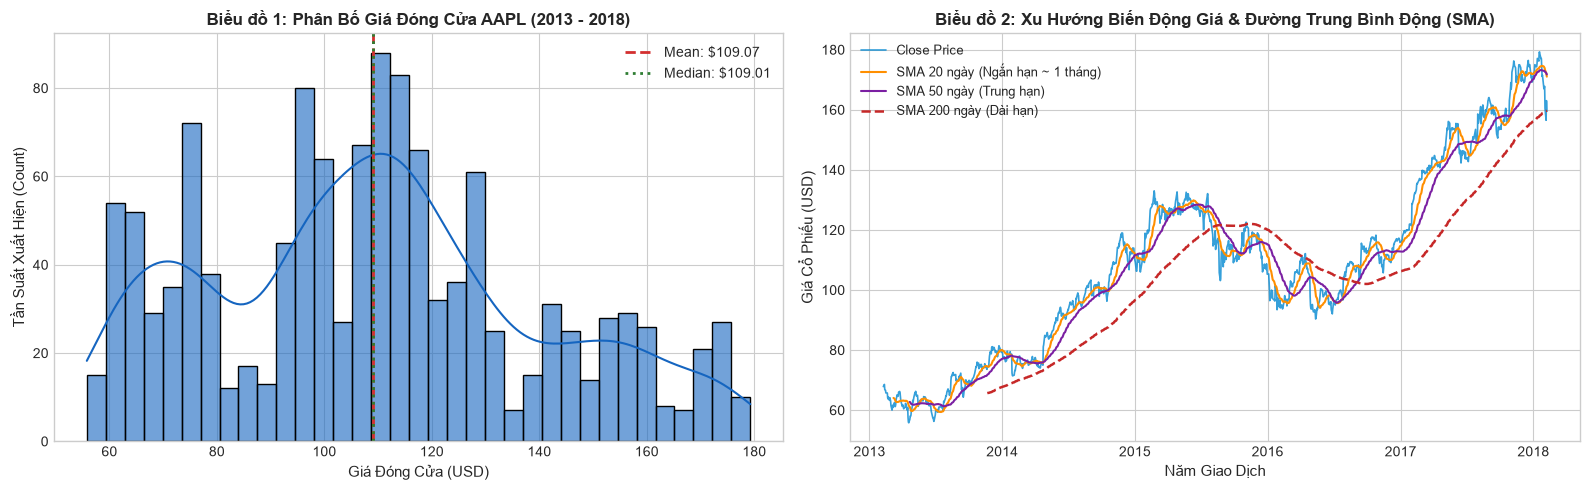

In [4]:
# 4.1. Trực quan hóa Biểu đồ 1 & 2: Phân bố giá và Xu hướng biến động theo thời gian
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 1: PHÂN BỐ GIÁ ĐÓNG CỬA (TARGET DISTRIBUTION) ---
sns.histplot(df_aapl['close'], kde=True, ax=axes[0], color='#1565C0', bins=35, edgecolor='black', alpha=0.6)
axes[0].axvline(df_aapl['close'].mean(), color='#D32F2F', linestyle='--', linewidth=2, label=f"Mean: ${df_aapl['close'].mean():.2f}")
axes[0].axvline(df_aapl['close'].median(), color='#2E7D32', linestyle=':', linewidth=2, label=f"Median: ${df_aapl['close'].median():.2f}")
axes[0].set_title("Biểu đồ 1: Phân Bố Giá Đóng Cửa AAPL (2013 - 2018)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Giá Đóng Cửa (USD)", fontsize=11)
axes[0].set_ylabel("Tần Suất Xuất Hiện (Count)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 2: XU HƯỚNG THEO THỜI GIAN VÀ ĐƯỜNG TRUNG BÌNH ĐỘNG (SMA) ---
df_aapl['SMA_20'] = df_aapl['close'].rolling(window=20).mean()
df_aapl['SMA_50'] = df_aapl['close'].rolling(window=50).mean()
df_aapl['SMA_200'] = df_aapl['close'].rolling(window=200).mean()

axes[1].plot(df_aapl['date'], df_aapl['close'], label='Close Price', color='#0288D1', linewidth=1.2, alpha=0.8)
axes[1].plot(df_aapl['date'], df_aapl['SMA_20'], label='SMA 20 ngày (Ngắn hạn ~ 1 tháng)', color='#FF8F00', linewidth=1.5)
axes[1].plot(df_aapl['date'], df_aapl['SMA_50'], label='SMA 50 ngày (Trung hạn)', color='#7B1FA2', linewidth=1.5)
axes[1].plot(df_aapl['date'], df_aapl['SMA_200'], label='SMA 200 ngày (Dài hạn)', color='#C62828', linewidth=1.8, linestyle='--')
axes[1].set_title("Biểu đồ 2: Xu Hướng Biến Động Giá & Đường Trung Bình Động (SMA)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[1].set_ylabel("Giá Cổ Phiếu (USD)", fontsize=11)
axes[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()


### Dữ liệu này phân bố như vậy có ý nghĩa gì?

#### 1. Ý nghĩa của Biểu đồ 1 (Phân bố xác suất của Target):
* **Phân bố đa đỉnh (Bimodal Distribution) & Không chuẩn (Non-Gaussian)**:
  * Đồ thị phân bố giá đóng cửa không tuân theo hình chuông chuẩn đối xứng Gauss. Thay vào đó, nó thể hiện rõ cấu trúc hai vùng đỉnh tập trung:
    * Vùng tích lũy thứ nhất: Khoảng $70 - 90$ USD (tập trung các phiên giao dịch từ năm 2013 đến đầu năm 2014).
    * Vùng tích lũy thứ hai: Khoảng $110 - 130$ USD (tập trung trong giai đoạn 2015 - 2016).
  * Vùng giá cao nhất ($150 - 180$ USD) xuất hiện ở đuôi bên phải tương ứng với chu kỳ tăng trưởng bùng nổ của năm 2017.
* **Ý nghĩa đối với mô hình mạng RNN**:
  * Biểu đồ thời gian gợi ý mức giá thay đổi giữa các giai đoạn; chưa thực hiện kiểm định tính dừng. Histogram đa đỉnh đơn thuần không đủ kết luận phi dừng.
  * Vì biên độ dao động trải rộng từ mức đáy $\$55.79$ lên tới đỉnh $\$179.26$ (gấp hơn 3 lần), nếu đưa trực tiếp dữ liệu thô vào các nơ-ron RNN sử dụng hàm kích hoạt phi tuyến tính $\tanh$, các giá trị đầu vào lớn sẽ ngay lập tức đẩy đạo hàm của $\tanh$ về vùng bão hòa triệt tiêu (Saturation Region), gây tê liệt quá trình lan truyền ngược gradient.
  * Do đó, bài dùng MinMaxScaler để cân bằng thang đo. Chỉ giá trị Train được đưa vào [0,1]; Val/Test có thể vượt khoảng này.

#### 2. Ý nghĩa của Biểu đồ 2 (Xu hướng thời gian & Đường trung bình SMA):
* **Xu hướng theo dữ liệu**: mức giá đầu và cuối giai đoạn khác nhau, xen kẽ các đợt tăng và giảm. Dataset OHLCV không đủ để quy nguyên nhân cho doanh thu sản phẩm hoặc dịch vụ.
* **Tính tự tương quan cao (High Autocorrelation)**: 
  * Giá của ngày hôm nay gắn liền mật thiết với mức giá của các ngày liền kề trước đó. Khi giá vượt lên trên các đường trung bình động SMA 20 ngày và SMA 50 ngày, quán tính tăng giá thường được duy trì liên tục trong nhiều tuần.
  * SMA 20 quan sát là trung bình động làm mịn giá; biểu đồ chưa kiểm chứng vai trò hỗ trợ/kháng cự hay lợi nhuận giao dịch.
  * Đây là minh chứng rõ ràng giải thích tại sao mô hình mạng nơ-ron hồi quy có bộ nhớ ngữ cảnh như RNN là công cụ phù hợp để học các mối liên hệ thời gian này.


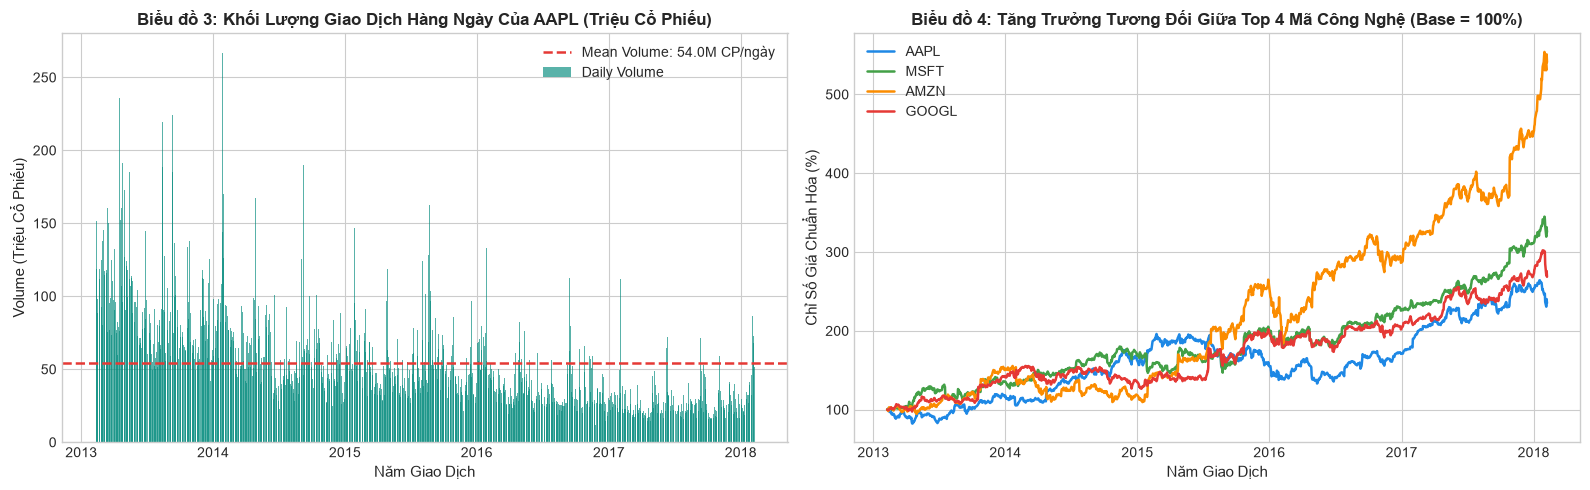

In [5]:
# 4.2. Trực quan hóa Biểu đồ 3: Khối lượng giao dịch & Biểu đồ 4: So sánh đa mã công nghệ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 3: KHỐI LƯỢNG GIAO DỊCH (VOLUME) THEO THỜI GIAN ---
mean_vol_m = df_aapl['volume'].mean() / 1e6
axes[0].bar(df_aapl['date'], df_aapl['volume'] / 1e6, color='#00897B', width=2, alpha=0.65, label='Daily Volume')
axes[0].axhline(mean_vol_m, color='#E53935', linestyle='--', linewidth=1.8, label=f"Mean Volume: {mean_vol_m:.1f}M CP/ngày")
axes[0].set_title("Biểu đồ 3: Khối Lượng Giao Dịch Hàng Ngày Của AAPL (Triệu Cổ Phiếu)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[0].set_ylabel("Volume (Triệu Cổ Phiếu)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 4: SO SÁNH TĂNG TRƯỞNG GIÁ GIỮA 4 MÃ CÔNG NGHỆ HÀNG ĐẦU (BASE 100) ---
top_tech = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
df_tech = df_raw[df_raw['Name'].isin(top_tech)].copy()
df_tech['date'] = pd.to_datetime(df_tech['date'])

# Chuẩn hóa về mốc 100% tại phiên giao dịch đầu tiên để so sánh khách quan tốc độ tăng trưởng
pivoted_close = df_tech.pivot(index='date', columns='Name', values='close').dropna()
normalized_growth = (pivoted_close / pivoted_close.iloc[0]) * 100

colors = {'AAPL': '#1E88E5', 'MSFT': '#43A047', 'AMZN': '#FB8C00', 'GOOGL': '#E53935'}
for ticker in top_tech:
    axes[1].plot(normalized_growth.index, normalized_growth[ticker], label=f"{ticker}", color=colors[ticker], linewidth=1.8)

axes[1].set_title("Biểu đồ 4: Tăng Trưởng Tương Đối Giữa Top 4 Mã Công Nghệ (Base = 100%)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[1].set_ylabel("Chỉ Số Giá Chuẩn Hóa (%)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Dữ liệu này phân bố như vậy có ý nghĩa gì?

#### 1. Ý nghĩa của Biểu đồ 3 (Khối lượng giao dịch - Volume Spikes):
* **Hiện tượng bùng nổ thanh khoản cục bộ (Volume Spikes)**:
  * Khối lượng giao dịch trung bình đạt xấp xỉ $54$ triệu cổ phiếu mỗi ngày. Tuy nhiên, trên biểu đồ xuất hiện nhiều cột mốc tăng vọt lên tới $150 - 260$ triệu cổ phiếu (gấp 3 đến 5 lần mức bình thường).
  * Dữ liệu có các phiên volume tăng mạnh; chưa có dữ liệu sự kiện để xác định nguyên nhân từng đỉnh.
* **Ý nghĩa đối với quá trình tiền xử lý**:
  * Cột `volume` có độ lớn dao động ở thang đo hàng chục triệu ($10^7$), trong khi các cột giá dao động ở thang đo hàng chục đến hàng trăm ($10^1 - 10^2$).
  * Thang đo volume lớn có thể gây mất cân bằng tổng tuyến tính và gradient. Chuẩn hóa từng thuộc tính hỗ trợ tối ưu, không có nghĩa volume trực tiếp nằm trong hàm loss của target giá.

#### 2. Ý nghĩa của Biểu đồ 4 (So sánh đa mã cổ phiếu):
* **Tính dị biệt giữa các thực thể (Entity Heterogeneity)**:
  * Dù cùng nằm trong nhóm cổ phiếu công nghệ danh tiếng nhất thị trường chứng khoán Mỹ, quỹ đạo tăng trưởng của từng doanh nghiệp là hoàn toàn khác biệt:
* **Hàm ý thiết kế bài toán RNN**:
  * Mỗi mã cổ phiếu là một hệ sinh thái tài chính với chu kỳ dòng tiền và độ nhạy cảm thị trường khác biệt.
  * Việc tập trung huấn luyện mô hình RNN trên chuỗi dữ liệu độc lập của một mã duy nhất (`AAPL`) là hướng tiếp cận chuẩn mực nhằm bảo toàn tính liên tục của chuỗi thời gian, loại bỏ hoàn toàn nhiễu tương tác chéo (cross-sectional noise).

> **Base 100**: Chỉ số 250 nghĩa là giá bằng 2.5 lần ban đầu, tức tăng 150%, không phải tăng 250%. Biểu đồ không xác định nguyên nhân kinh doanh của mức tăng.


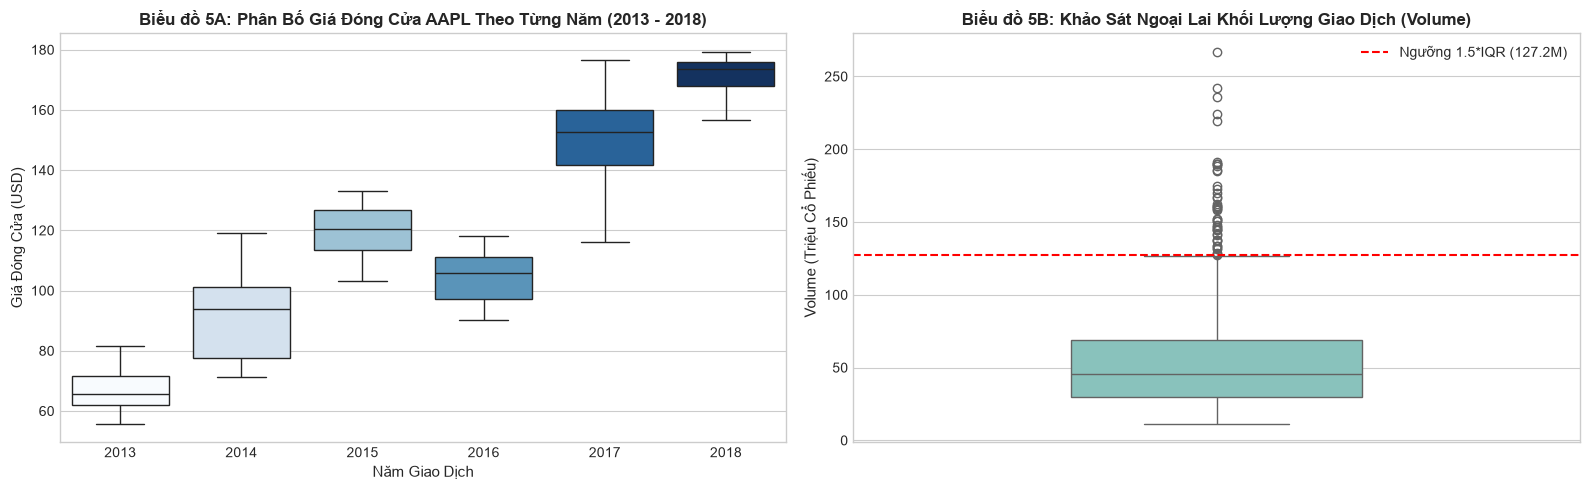

In [6]:
# 4.3. Trực quan hóa Biểu đồ 5: Phân tích Outliers theo năm và Phân bố Khối lượng
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 5A: BOXPLOT GIÁ ĐÓNG CỬA THEO TỪNG NĂM (OUTLIER & ANNUAL SHIFT) ---
sns.boxplot(x='year', y='close', data=df_aapl, ax=axes[0], hue='year', legend=False, palette='Blues')
axes[0].set_title("Biểu đồ 5A: Phân Bố Giá Đóng Cửa AAPL Theo Từng Năm (2013 - 2018)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[0].set_ylabel("Giá Đóng Cửa (USD)", fontsize=11)

# --- BIỂU ĐỒ 5B: BOXPLOT & PHÂN PHỐI CỦA KHỐI LƯỢNG GIAO DỊCH (VOLUME OUTLIERS) ---
sns.boxplot(y=df_aapl['volume'] / 1e6, ax=axes[1], color='#80CBC4', width=0.4)
axes[1].set_title("Biểu đồ 5B: Khảo Sát Ngoại Lai Khối Lượng Giao Dịch (Volume)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Volume (Triệu Cổ Phiếu)", fontsize=11)

# Thống kê số lượng điểm ngoại lai trên đồ thị
vol_q3 = df_aapl['volume'].quantile(0.75) / 1e6
vol_q1 = df_aapl['volume'].quantile(0.25) / 1e6
vol_iqr = vol_q3 - vol_q1
vol_upper = vol_q3 + 1.5 * vol_iqr
axes[1].axhline(vol_upper, color='red', linestyle='--', linewidth=1.5, label=f"Ngưỡng 1.5*IQR ({vol_upper:.1f}M)")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Dữ liệu này phân bố như vậy có ý nghĩa gì?

#### 1. Ý nghĩa của Biểu đồ 5A (Phân bố theo năm & Đánh giá Outlier của Target):
* **IQR toàn cục** của `close` phát hiện **0 điểm nằm ngoài hàng rào IQR**. Kết quả này phụ thuộc ngưỡng tính từ Q1/Q3, không phải do mọi giá trị nằm trong min/max của chính chúng.
* Phân bố theo năm khác nhau; điểm ngoài râu hộp chỉ là dấu hiệu thống kê, chưa chứng minh lỗi dữ liệu hay sự kiện định giá.
* Giữ các quan sát giá hiện có vì chưa có bằng chứng để loại bỏ. Việc chọn ngưỡng xử lý cho mô hình phải dựa trên Train, không dựa vào Test.

#### 2. Ý nghĩa của Biểu đồ 5B (Khảo sát ngoại lai của Khối lượng - Volume Outliers):
* Ngưỡng IQR trên của `volume` là **127,230,235.25** cổ phiếu, có **46 phiên** vượt hàng rào, tương đương **3.65%** số quan sát.
* Các điểm này được giữ trong thực nghiệm. MinMaxScaler fit trên Train không bảo đảm mọi giá trị tương lai nằm trong [0,1], cũng không tự loại bỏ tác động của outlier.


---
<a id="section-5"></a>
## 5. Thiết Kế Bài Toán RNN & Lựa Chọn Target / Features

### 5.1. Định nghĩa bài toán dự đoán:
Chúng ta thiết kế bài toán dự báo chuỗi thời gian một bước tới trong tương lai (**One-Step-Ahead Time-Series Forecasting**):
* Dựa trên chuỗi quan sát gồm $L$ phiên giao dịch liên tiếp trong quá khứ: $[x_{t-L+1}, x_{t-L+2}, \dots, x_t]$.
* Dự đoán giá trị của phiên tiếp theo ngay sau cửa sổ quan sát: $y = \text{close}_{t+1}$.

---

### 5.2. Quyết định lựa chọn Biến mục tiêu (Target Variable) có lý do cụ thể:
* **Biến mục tiêu lựa chọn**: **Giá đóng cửa của phiên kế tiếp (`close` tại $t+1$)**.
* **Rationale (Lý do cụ thể)**:
  1. **Chuẩn mực định giá tài chính**: Mức giá đóng cửa (`close`) là mức giá thỏa thuận cuối cùng của ngày giao dịch, tích lũy toàn bộ thông tin xuất hiện trong ngày và là cơ sở tính toán giá trị tài sản ròng (NAV), lợi nhuận danh mục và chỉ số phái sinh trên toàn cầu.
  2. **Thời điểm dự báo**: Chỉ dùng OHLCV phiên hiện tại sau khi phiên đã kết thúc. Bài chưa mô phỏng lệnh giao dịch hoặc khẳng định có thể khớp lệnh tại giá đóng cửa vừa quan sát.

---

### 5.3. Quyết định lựa chọn Bộ đặc trưng đầu vào (Input Features) có lý do cụ thể:
* Chúng ta thiết lập bài toán **Dự báo Đa biến (Multivariate Forecasting)** gồm **5 đặc trưng cốt lõi**:
  $$\text{Features} = [\text{'open'}, \text{'high'}, \text{'low'}, \text{'close'}, \text{'volume'}]$$
* **Rationale (Lý do cụ thể)**:
  1. **Đặc trưng OHLC (`open`, `high`, `low`, `close`)**: Thể hiện đầy đủ cấu trúc của một cây nến Nhật Bản (Candlestick). Khoảng cách giữa `high` và `low` biểu thị độ biến động nội phiên (Intraday Volatility); độ chênh lệch giữa `open` và `close` phản ánh áp lực bên mua áp đảo bên bán hay ngược lại.
  2. **Khối lượng (`volume`)**: Mô tả lượng cổ phiếu giao dịch. Khả năng bổ sung tín hiệu dự báo phải được kiểm chứng; không mặc định volume thấp là bull-trap.
  3. **Kích thước đầu vào**: **`input_size = 5`**.

Đoạn code bên dưới sẽ tính toán ma trận tương quan giữa 5 đặc trưng này để kiểm chứng mối quan hệ định lượng giữa chúng.


=== MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON (CORRELATION MATRIX) ===


,open,high,low,close,volume
open,1.000000,0.999584,0.999515,0.999118,-0.617862
high,0.999584,1.000000,0.999382,0.999584,-0.612622
low,0.999515,0.999382,1.000000,0.999614,-0.625910
close,0.999118,0.999584,0.999614,1.000000,-0.620290
volume,-0.617862,-0.612622,-0.625910,-0.620290,1.000000


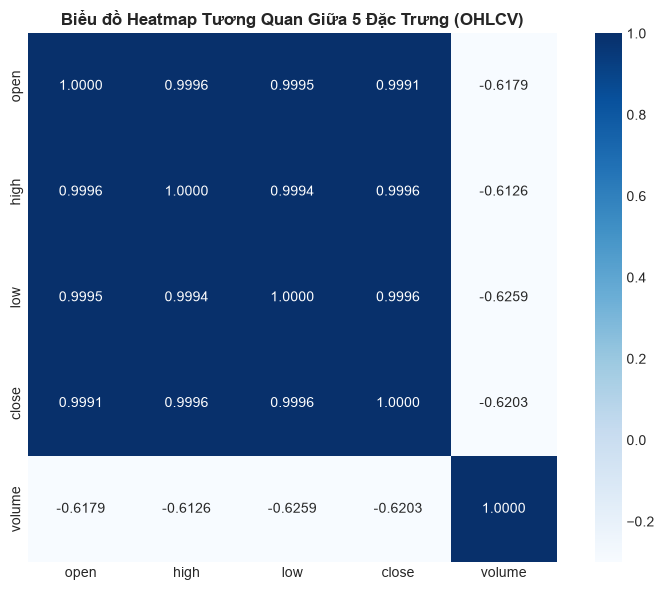

In [7]:
# 5. Tính toán ma trận hệ số tương quan (Correlation Matrix) giữa 5 đặc trưng
feature_cols = ['open', 'high', 'low', 'close', 'volume']
corr_matrix = df_aapl[feature_cols].corr()

print("=== MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON (CORRELATION MATRIX) ===")
display(corr_matrix)

# Trực quan hóa Heatmap tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap='Blues', vmin=-0.3, vmax=1.0, cbar=True, square=True)
plt.title("Biểu đồ Heatmap Tương Quan Giữa 5 Đặc Trưng (OHLCV)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Phân tích ý nghĩa Ma trận tương quan:
* **OHLC cùng ngày có tương quan cao**: Các cột mô tả cùng mức giá trong một phiên nên biến động cùng nhau. Điều này chưa chứng minh chúng dự báo được giá phiên sau.
* **Close và volume có Pearson $r=-0.6203$** trên toàn giai đoạn AAPL. Đây là tương quan âm quan sát được, không phải tương quan âm nhẹ -0.19.
* Không suy ra nguyên nhân volume giảm do giá tăng chỉ từ hệ số tương quan. Input vẫn chỉ gồm các quan sát trước target; EDA toàn kỳ mang tính mô tả, không dùng để fit scaler hoặc chọn siêu tham số theo Test.


---
<a id="section-6"></a>
## 6. Phân Chia Train / Validation / Test Theo Trục Thời Gian

Trong một số bài toán dữ liệu độc lập, có thể chia ngẫu nhiên Train/Test. Với dự báo tương lai, bài này chia theo thời gian để tránh huấn luyện bằng các quan sát xảy ra sau giai đoạn kiểm thử.

---

### 6.1. Tại sao bắt buộc phải chia theo trật tự thời gian (Chronological Split)?
1. **Phòng chống Rò rỉ thông tin tương lai (Look-ahead Data Leakage)**:
   * Nếu xáo trộn dữ liệu, một phiên giao dịch của năm 2017 có thể lọt vào tập Train, trong khi phiên giao dịch của năm 2015 lại rơi vào tập Test. Khi đó, mô hình sẽ dùng dữ liệu tương lai để "dự báo" quá khứ.
   * Kết quả đánh giá trên giấy tờ sẽ đạt độ chính xác giả tạo cực cao, nhưng mô hình sẽ thất bại hoàn toàn khi ứng dụng thực tế.
2. **Quy tắc chia nối tiếp bất biến**:
   $$\text{Quá khứ xa (Train: 70\%)} \longrightarrow \text{Quá khứ gần (Validation: 15\%)} \longrightarrow \text{Tương lai gần nhất (Test: 15\%)} $$

---

### 6.2. Tỉ lệ và mốc thời gian cụ thể:
* **Tổng số quan sát**: $1,259$ ngày giao dịch.
* **Tập Huấn luyện (Train Set - 70%)**: $881$ ngày (từ 08/02/2013 đến 08/08/2016). Dùng để cập nhật trọng số mạng nơ-ron.
* **Tập Đánh giá (Validation Set - 15%)**: $188$ ngày (từ 09/08/2016 đến 08/05/2017). Dùng để theo dõi hàm mất mát, tinh chỉnh siêu tham số và áp dụng Early Stopping.
* **Tập Kiểm thử (Test Set - 15%)**: $190$ ngày (từ 09/05/2017 đến 07/02/2018). Dùng để đánh giá độc lập năng lực dự báo trong điều kiện thị trường thực tế chưa từng thấy.


=== KẾT QUẢ PHÂN CHIA DỮ LIỆU THEO TRẬT TỰ THỜI GIAN ===
Tổng số ngày: 1259 phiên (100%)
1. Tập Train (70%)     : 881  ngày | Từ 2013-02-08 đến 2016-08-08
2. Tập Validation (15%): 188  ngày | Từ 2016-08-09 đến 2017-05-08
3. Tập Test (15%)      : 190  ngày | Từ 2017-05-09 đến 2018-02-07


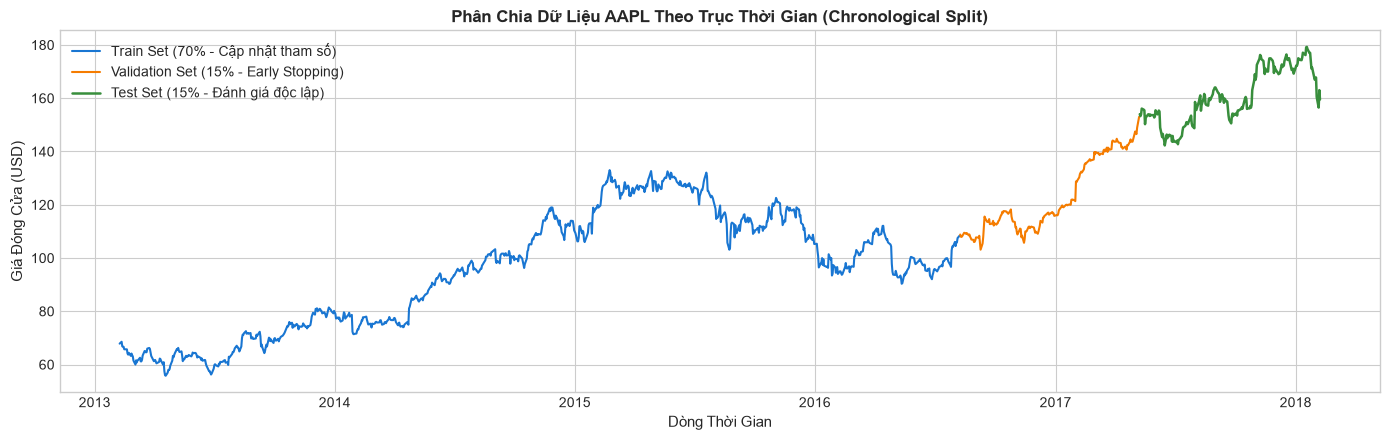

In [8]:
# 6. Thực hiện phân chia tập dữ liệu nối tiếp theo dòng thời gian
data_values = df_aapl[feature_cols].values
dates = df_aapl['date'].values

n_total = len(df_aapl)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)
n_test  = n_total - n_train - n_val

# Chia các lát cắt dữ liệu nối tiếp
train_raw_data = data_values[:n_train]
val_raw_data   = data_values[n_train : n_train + n_val]
test_raw_data  = data_values[n_train + n_val :]

train_dates = dates[:n_train]
val_dates   = dates[n_train : n_train + n_val]
test_dates  = dates[n_train + n_val :]

print("=== KẾT QUẢ PHÂN CHIA DỮ LIỆU THEO TRẬT TỰ THỜI GIAN ===")
print(f"Tổng số ngày: {n_total} phiên (100%)")
print(f"1. Tập Train (70%)     : {len(train_raw_data):<4} ngày | Từ {pd.to_datetime(train_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(train_dates[-1]).strftime('%Y-%m-%d')}")
print(f"2. Tập Validation (15%): {len(val_raw_data):<4} ngày | Từ {pd.to_datetime(val_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(val_dates[-1]).strftime('%Y-%m-%d')}")
print(f"3. Tập Test (15%)      : {len(test_raw_data):<4} ngày | Từ {pd.to_datetime(test_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(test_dates[-1]).strftime('%Y-%m-%d')}")

# Vẽ biểu đồ phân định 3 tập dữ liệu
plt.figure(figsize=(14, 4.5))
plt.plot(train_dates, train_raw_data[:, 3], label='Train Set (70% - Cập nhật tham số)', color='#1976D2', linewidth=1.5)
plt.plot(val_dates, val_raw_data[:, 3], label='Validation Set (15% - Early Stopping)', color='#F57C00', linewidth=1.5)
plt.plot(test_dates, test_raw_data[:, 3], label='Test Set (15% - Đánh giá độc lập)', color='#388E3C', linewidth=1.8)
plt.title("Phân Chia Dữ Liệu AAPL Theo Trục Thời Gian (Chronological Split)", fontsize=12, fontweight='bold')
plt.xlabel("Dòng Thời Gian", fontsize=11)
plt.ylabel("Giá Đóng Cửa (USD)", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
<a id="section-7"></a>
## 7. Chuẩn Hóa Dữ Liệu (Scaling) & Phòng Chống Rò Rỉ Dữ Liệu

### 7.1. Lựa chọn thuật toán chuẩn hóa:
* Chúng ta sử dụng **`MinMaxScaler(feature_range=(0, 1))`**.
* Công thức chuyển đổi:
  $$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
* **Lý do**:
  * Hàm kích hoạt phổ biến trong tế bào RNN là hàm Tanghypebolic ($\tanh$) có miền giá trị hữu hạn trong khoảng $[-1, 1]$ và đạo hàm đạt giá trị lớn nhất tại lân cận số 0.
  * Scale từng đặc trưng bằng min/max của Train làm giảm chênh lệch thang đo; phép biến đổi tuyến tính này không làm phân bố đối xứng hay bảo đảm hội tụ.

---

### 7.2. Nguyên tắc sống còn: CHỈ FIT TRÊN TẬP TRAIN!
* **Quy trình chuẩn hóa đúng khoa học**:
  ```python
  scaler.fit(train_raw_data)                       # CHỈ học min, max từ tập Train!
  scaled_train_x = scaler.transform(train_raw_data)
  scaled_val_x   = scaler.transform(val_raw_data)   # Transform Val bằng min, max của Train
  scaled_test_x  = scaler.transform(test_raw_data)  # Transform Test bằng min, max của Train
  ```
* **Tại sao không được phép gọi `scaler.fit` trên toàn bộ tập dữ liệu?**
  * Nếu ta fit trên toàn bộ tập dữ liệu, giá trị $x_{\max}$ và $x_{\min}$ của năm 2018 (tương lai) sẽ được dùng để chuẩn hóa dữ liệu của năm 2013 (quá khứ). Mô hình khi đó sẽ gián tiếp biết trước trần giá và đáy giá của tương lai $\implies$ Vi phạm nguyên tắc bảo mật thông tin tương lai (*Look-ahead Bias*).
* **Tạo riêng `target_scaler` cho cột mục tiêu**:
  * Ta tạo một đối tượng `target_scaler` độc lập dành riêng cho cột `close` (cột chỉ số 3).
  * Đối tượng này sẽ được lưu giữ để ở pha suy luận (Inference Phase), ta có thể gọi hàm `target_scaler.inverse_transform()` chuyển đổi các giá trị dự báo từ $[0, 1]$ trở về đơn vị tiền tệ USD thực tế.


In [9]:
# 7. Chuẩn hóa dữ liệu tuân thủ nghiêm ngặt nguyên tắc chỉ Fit trên Train
from sklearn.preprocessing import MinMaxScaler

# 1. Feature Scaler cho toàn bộ 5 đặc trưng
feature_scaler = MinMaxScaler(feature_range=(0, 1))

# FIT CHỈ TRÊN TẬP TRAIN
feature_scaler.fit(train_raw_data)

# Transform độc lập trên từng tập
scaled_train_x = feature_scaler.transform(train_raw_data)
scaled_val_x   = feature_scaler.transform(val_raw_data)
scaled_test_x  = feature_scaler.transform(test_raw_data)

# 2. Target Scaler độc lập cho cột 'close' (cột index 3)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_raw_data[:, [3]])

print("=== CÁC THAM SỐ CỦA BỘ SCALER (CHỈ HỌC TỪ TẬP TRAIN) ===")
for col, min_v, max_v in zip(feature_cols, feature_scaler.data_min_, feature_scaler.data_max_):
    print(f"Đặc trưng {col:<8}: Min = {min_v:>12.2f} | Max = {max_v:>12.2f}")

print("\nKiểm tra khoảng giá trị sau khi Transform:")
print(f"Train Set : Min = {scaled_train_x.min():.4f}, Max = {scaled_train_x.max():.4f}")
print(f"Val Set   : Min = {scaled_val_x.min():.4f}, Max = {scaled_val_x.max():.4f}")
print(f"Test Set  : Min = {scaled_test_x.min():.4f}, Max = {scaled_test_x.max():.4f}")
print("-> Ghi chú: Giá trị trên tập Test có thể vượt nhẹ ngưỡng 1.0 vì giá cổ phiếu năm 2017-2018 lập đỉnh lịch sử mới vượt đỉnh của tập Train. Đây là hiện tượng hoàn toàn bình thường trong dữ liệu thời gian thực tế!")


=== CÁC THAM SỐ CỦA BỘ SCALER (CHỈ HỌC TỪ TẬP TRAIN) ===
Đặc trưng open    : Min =        55.42 | Max =       134.46
Đặc trưng high    : Min =        57.09 | Max =       134.54
Đặc trưng low     : Min =        55.01 | Max =       131.40
Đặc trưng close   : Min =        55.79 | Max =       133.00
Đặc trưng volume  : Min =  13046445.00 | Max = 266833581.00

Kiểm tra khoảng giá trị sau khi Transform:
Train Set : Min = 0.0000, Max = 1.0000
Val Set   : Min = -0.0062, Max = 1.2592
Test Set  : Min = 0.0039, Max = 1.6133
-> Ghi chú: Giá trị trên tập Test có thể vượt nhẹ ngưỡng 1.0 vì giá cổ phiếu năm 2017-2018 lập đỉnh lịch sử mới vượt đỉnh của tập Train. Đây là hiện tượng hoàn toàn bình thường trong dữ liệu thời gian thực tế!


---
<a id="section-8"></a>
## 8. Tạo Cấu Trúc Cửa Sổ Trượt (Sliding Windows) Cho RNN

Sau khi dữ liệu đã được chuẩn hóa theo trật tự thời gian, bước tiếp theo là chuyển đổi mảng dữ liệu 2D phẳng thành các mẫu **Tensor 3D** phục vụ cho mô hình RNN:

### 8.1. Cấu trúc kích thước mong muốn:
* **Ma trận đầu vào $X$**: Kích thước `(num_samples, sequence_length, num_features)` $\implies (M, 20, 5)$.
* **Vector nhãn mục tiêu $y$**: Kích thước `(num_samples,)` $\implies (M,)$.

---

### 8.2. Biện luận khoa học về việc chọn `sequence_length = 20`:
1. **Chu kỳ giao dịch thực tế**: Trong thị trường tài chính Mỹ, mỗi tuần có 5 ngày làm việc. Một tháng giao dịch (trading month) có trung bình đúng **20 đến 21 phiên**. Do đó, $L = 20$ đại diện trọn vẹn cho 1 tháng vận động của dòng tiền.
2. **Nắm bắt đà tăng trưởng ngắn hạn**: Cửa sổ 20 phiên tương thích hoàn hảo với chỉ báo đường trung bình động SMA 20 ngày phổ biến của giới đầu tư.
3. **Chi phí và ngữ cảnh**: $L=20$ là cấu hình ban đầu, không phải một vùng an toàn bảo đảm gradient không suy giảm. Muốn chọn độ dài tối ưu phải so sánh bằng validation.

---

### 8.3. Hàm tạo Sliding Window:
Hàm `create_sliding_sequences` trượt một khung cửa sổ $L = 20$ qua từng hàng, trích xuất mảng $20 \times 5$ làm đầu vào $X_i$, và lấy giá trị `close` tại vị trí kế tiếp ngay sau cửa sổ ($t+20$) làm nhãn $y_i$.

> **Giao thức**: Cửa sổ được tạo riêng trong mỗi split; 20 phiên đầu mỗi split làm context. Test có **170 target từ 07/06/2017 đến 07/02/2018**, dự báo từng bước với lịch sử thực đã quan sát, chưa phải dự báo đệ quy toàn bộ giai đoạn.


In [10]:
# 8. Xây dựng hàm tạo chuỗi cửa sổ trượt (Sliding Sequences)
def create_sliding_sequences(data_array, target_idx=3, seq_length=20):
    """
    Chuyển đổi mảng dữ liệu chuỗi 2D thành các mẫu Tensor 3D (X) và nhãn 1D (y).
    
    Tham số:
        data_array (np.ndarray): Mảng 2D (num_timesteps, num_features).
        target_idx (int): Vị trí cột làm mục tiêu dự đoán (mặc định 3 là cột 'close').
        seq_length (int): Độ dài cửa sổ quan sát lịch sử (mặc định 20 bước).
        
    Trả về:
        X (np.ndarray): Mảng 3D kích thước (N - seq_length, seq_length, num_features).
        y (np.ndarray): Mảng 1D kích thước (N - seq_length,).
    """
    X_list, y_list = [], []
    total_len = len(data_array)
    
    for i in range(total_len - seq_length):
        # Lấy seq_length hàng liên tiếp làm ma trận đặc trưng đầu vào
        seq_x = data_array[i : i + seq_length, :]
        # Lấy giá trị target tại hàng tiếp theo ngay sau cửa sổ
        target_y = data_array[i + seq_length, target_idx]
        
        X_list.append(seq_x)
        y_list.append(target_y)
        
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

sequence_length = 20

# Áp dụng hàm trên từng tập dữ liệu đã chuẩn hóa
X_train, y_train = create_sliding_sequences(scaled_train_x, target_idx=3, seq_length=sequence_length)
X_val,   y_val   = create_sliding_sequences(scaled_val_x,   target_idx=3, seq_length=sequence_length)
X_test,  y_test  = create_sliding_sequences(scaled_test_x,  target_idx=3, seq_length=sequence_length)

print("=== KIỂM TRA MẪU ĐẦU TIÊN CỦA TẬP TRAIN (INDEX 0) ===")
print(f"Hình dạng cửa sổ X[0] : {X_train[0].shape} (20 bước thời gian, mỗi bước 5 đặc trưng)")
print(f"Giá trị target y[0]   : {y_train[0]:.4f} (Giá 'close' đã scale tại bước t=20)")
orig_price = target_scaler.inverse_transform([[y_train[0]]])[0][0]
print(f"-> Quy đổi ngược về giá thực tế: ${orig_price:.2f} USD")


# Kiểm chứng cửa sổ: nhãn luôn là bước ngay sau input; scaler chỉ fit Train.
for split_x, split_y, scaled in [(X_train, y_train, scaled_train_x), (X_val, y_val, scaled_val_x), (X_test, y_test, scaled_test_x)]:
    assert split_x.shape == (len(scaled) - sequence_length, sequence_length, len(feature_cols))
    assert np.isfinite(split_x).all() and np.isfinite(split_y).all()
    np.testing.assert_allclose(split_x[0], scaled[:sequence_length], rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(split_y, scaled[sequence_length:, 3], rtol=1e-6, atol=1e-7)
np.testing.assert_allclose(feature_scaler.data_min_, train_raw_data.min(axis=0))
np.testing.assert_allclose(feature_scaler.data_max_, train_raw_data.max(axis=0))
assert train_dates[-1] < val_dates[0] and val_dates[-1] < test_dates[0]
print("-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.")


=== KIỂM TRA MẪU ĐẦU TIÊN CỦA TẬP TRAIN (INDEX 0) ===
Hình dạng cửa sổ X[0] : (20, 5) (20 bước thời gian, mỗi bước 5 đặc trưng)
Giá trị target y[0]   : 0.0876 (Giá 'close' đã scale tại bước t=20)
-> Quy đổi ngược về giá thực tế: $62.55 USD
-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.


---
<a id="section-9"></a>
## 9. Chuyển Đổi Dữ Liệu Thành Định Dạng Tương Thích TensorFlow / Keras

Trong hệ sinh thái **TensorFlow / Keras**, các lớp hồi quy tuần tự như `keras.layers.SimpleRNN`, `keras.layers.LSTM`, `keras.layers.GRU` nhận dữ liệu đầu vào theo chuẩn mực:
* **Chuẩn NumPy 3D Array**: `(batch_size, timesteps, features)` kiểu `np.float32`.
* **Chuẩn Pipeline `tf.data.Dataset`**: Cấu trúc tối ưu hóa nạp dữ liệu song song từ bộ nhớ, hỗ trợ đóng lô (`.batch()`), xáo trộn nội bộ lô nếu cần và chuẩn bị trước dữ liệu trên bộ nhớ đệm (`.prefetch(tf.data.AUTOTUNE)`).

---

### Yêu cầu hiển thị rõ ràng kích thước các mảng:
Đoạn code bên dưới sẽ in rõ ràng các shape của 6 mảng dữ liệu theo đúng yêu cầu đề bài:
* `X_train.shape`, `y_train.shape`
* `X_val.shape`, `y_val.shape`
* `X_test.shape`, `y_test.shape`
Đồng thời đóng gói thành các đối tượng `tf.data.Dataset` sẵn sàng cho Keras.


In [11]:
# 9. In rõ ràng kích thước các tập dữ liệu và đóng gói TensorFlow Dataset
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf

print("================================================================================")
print("=== KÍCH THƯỚC CHÍNH XÁC CỦA DỮ LIỆU ĐÃ CHUYỂN ĐỔI SANG ĐỊNH DẠNG KERAS ===")
print("================================================================================")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_val.shape  : {X_val.shape}")
print(f"y_val.shape  : {y_val.shape}")
print(f"X_test.shape : {X_test.shape}")
print(f"y_test.shape : {y_test.shape}")
print("================================================================================")

# Kiểm tra kiểu dữ liệu của các mảng
print(f"Kiểu dữ liệu của X: {X_train.dtype} | Kiểu dữ liệu của y: {y_train.dtype}")

# Thiết lập Batch size chuẩn
BATCH_SIZE = 32

# Đóng gói dữ liệu thành các pipeline tf.data.Dataset hiệu năng cao
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n=== KIỂM TRA TENSORFLOW tf.data.Dataset PIPELINE ===")
print(f"Batch size cấu hình: {BATCH_SIZE}")
print(f"Số lượng batches trong train_dataset: {len(train_dataset)} batches ({len(X_train)} mẫu)")
print(f"Số lượng batches trong val_dataset  : {len(val_dataset)} batches ({len(X_val)} mẫu)")
print(f"Số lượng batches trong test_dataset : {len(test_dataset)} batches ({len(X_test)} mẫu)")

# Trích xuất thử một batch đầu tiên từ train_dataset để xác thực shape
for batch_x, batch_y in train_dataset.take(1):
    print(f"\nThông số Batch đầu tiên trích xuất từ tf.data.Dataset:")
    print(f"  -> batch_x.shape: {batch_x.shape} (batch_size, timesteps, features)")
    print(f"  -> batch_y.shape: {batch_y.shape} (batch_size,)")
    print(f"  -> batch_x dtype: {batch_x.dtype}, batch_y dtype: {batch_y.dtype}")


print("-> tf.data.Dataset ở đây minh họa cách đóng gói; model.fit bên dưới sử dụng trực tiếp NumPy X/y.")


=== KÍCH THƯỚC CHÍNH XÁC CỦA DỮ LIỆU ĐÃ CHUYỂN ĐỔI SANG ĐỊNH DẠNG KERAS ===
X_train.shape: (861, 20, 5)
y_train.shape: (861,)
X_val.shape  : (168, 20, 5)
y_val.shape  : (168,)
X_test.shape : (170, 20, 5)
y_test.shape : (170,)
Kiểu dữ liệu của X: float32 | Kiểu dữ liệu của y: float32

=== KIỂM TRA TENSORFLOW tf.data.Dataset PIPELINE ===
Batch size cấu hình: 32
Số lượng batches trong train_dataset: 27 batches (861 mẫu)
Số lượng batches trong val_dataset  : 6 batches (168 mẫu)
Số lượng batches trong test_dataset : 6 batches (170 mẫu)

Thông số Batch đầu tiên trích xuất từ tf.data.Dataset:
  -> batch_x.shape: (32, 20, 5) (batch_size, timesteps, features)
  -> batch_y.shape: (32,) (batch_size,)
  -> batch_x dtype: <dtype: 'float32'>, batch_y dtype: <dtype: 'float32'>
-> tf.data.Dataset ở đây minh họa cách đóng gói; model.fit bên dưới sử dụng trực tiếp NumPy X/y.


---
<a id="section-10"></a>
## 10. Ready for Keras RNN

Toàn bộ quy trình nạp dữ liệu thực tế S&P 500, phân tích khám phá toàn diện (EDA), làm sạch, phân chia thời gian, chuẩn hóa chống Data Leakage, tạo cửa sổ trượt và đóng gói tensor TensorFlow / Keras đã hoàn thành với độ chính xác và tính toàn vẹn cao nhất!

---

### 10.1. Bảng Tổng Kết Kỹ Thuật (Data Specifications):

| Thông số kỹ thuật | Giá trị cấu hình | Ý nghĩa & Mô tả chi tiết |
| :--- | :--- | :--- |
| **Mã cổ phiếu lựa chọn** | **`AAPL`** (Apple Inc.) | 1,259 ngày giao dịch liên tục, đầy đủ, không rỗng, thanh khoản hàng đầu. |
| **Khung thời gian khảo sát** | **`2013-02-08` $\to$ `2018-02-07`** | Tròn 5 năm quan sát giá và khối lượng của AAPL thực tế. |
| **`sequence_length`** | **`20` ngày giao dịch** | Xấp xỉ 1 tháng giao dịch trên thị trường tài chính Mỹ. |
| **`input_size`** | **`5` đặc trưng** | Bao gồm đầy đủ `['open', 'high', 'low', 'close', 'volume']` (OHLCV). |
| **`target`** | **`close` tại thời điểm $t+1$** | Giá đóng cửa phiên kế tiếp (USD) — Chuẩn mực định giá đầu tư tài chính. |
| **Phương pháp chuẩn hóa** | `MinMaxScaler(0, 1)` | Fit trên tập Train, Transform trên Val/Test để chống rò rỉ dữ liệu. |
| **Quy chuẩn Input Tensor** | `(num_samples, 20, 5)` | Mảng 3D kiểu `np.float32` hoàn toàn tương thích với `keras.layers.SimpleRNN`. |
| **Quy chuẩn Target Tensor** | `(num_samples,)` | Giá trị thực liên tục phục vụ bài toán Hồi quy (Regression). |
| **`train size`** | **`861` mẫu** ($861$ cửa sổ trượt $20$ bước) | Dùng để cập nhật tham số mạng nơ-ron qua thuật toán BPTT. |
| **`validation size`** | **`168` mẫu** ($168$ cửa sổ trượt $20$ bước) | Dùng để kiểm tra tổng quát hóa và kích hoạt cơ chế Early Stopping. |
| **`test size`** | **`170` mẫu** ($170$ cửa sổ trượt $20$ bước) | Dùng để đánh giá độc lập mô hình cuối cùng trên dữ liệu thực tế. |
| **Batch Size cấu hình** | **`32`** | Đóng gói tối ưu hóa thông lượng tính toán song song trên CPU/GPU. |

Dữ liệu đã hoàn toàn sẵn sàng. Chúng ta bước sang **Phần 2: Xây dựng, Huấn luyện và Đánh giá Mô hình Keras RNN**!


# PHẦN 2: XÂY DỰNG, HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH KERAS RNN

---

Trong phần này, chúng ta triển khai trọn vẹn mô hình mạng nơ-ron hồi quy bằng **TensorFlow / Keras**:
1. **Xây dựng Model**: Sử dụng `tf.keras.Sequential` với `tf.keras.layers.SimpleRNN` và `tf.keras.layers.Dense`. Tuyệt đối không dùng LSTM hay GRU.
2. **Compile**: Cấu hình bộ tối ưu `Adam` và hàm mất mát `MSE` với luận giải chi tiết.
3. **Huấn luyện**: Sử dụng `model.fit()` với `validation_data=(X_val, y_val)`, không shuffle time series gây leakage, tích hợp callback `EarlyStopping`.
4. **Đường cong học tập**: Vẽ biểu đồ Training Loss vs Validation Loss trên cả thang đo tuyến tính và logarit.
5. **Dự đoán**: Gọi `model.predict()`, thực hiện `inverse_transform` đưa về đơn vị USD thực tế.
6. **Đo lường định lượng**: Tính toán đầy đủ 4 chỉ số MAE, MSE, RMSE, MAPE.
7. **Trực quan hóa**: Vẽ đồ thị Actual vs Predicted và Residuals.
8. **Phân tích chuyên sâu**: Luận giải kết quả, sai số, hiện tượng trễ pha (phase lag), SNR thấp và giới hạn của RNN trong tài chính.
9. **PyTorch vs Keras implementation**: Bảng so sánh 6 khía cạnh kỹ thuật thuần túy giữa 2 framework (không xếp hạng).
10. **Conclusion**: Tổng kết toàn diện notebook.


---
<a id="section-11"></a>
## 11. Xây Dựng Model Bằng TensorFlow/Keras

Chúng ta xây dựng mô hình **Vanilla RNN** bằng API cấp cao `tf.keras.Sequential`, tuân thủ nghiêm ngặt các yêu cầu:
* Sử dụng `tf.keras.layers.SimpleRNN` tiếp nối bởi `tf.keras.layers.Dense`.
* **Tuyệt đối không sử dụng LSTM hay GRU**.
* Kiến trúc tương đương về mặt bài toán với notebook PyTorch (`01_RNN_PyTorch_Stock.ipynb`), nhưng triển khai theo chuẩn cú pháp Keras hiện đại.

---

### 11.1. Cấu trúc mô hình tổng quát:
$$\text{Input } (B, 20, 5) \longrightarrow \mathbf{\text{tf.keras.layers.SimpleRNN}(\text{units}=32, \text{activation}='\tanh')} \longrightarrow \mathbf{\text{tf.keras.layers.Dense}(\text{units}=1)} \longrightarrow \hat{y} \in \mathbb{R}^{B \times 1}$$

---

### 11.2. Phân tích chi tiết các lớp và luồng Tensor:
1. **`tf.keras.layers.Input(shape=(20, 5))`**:
   * Định nghĩa kích thước đầu vào rõ ràng: mỗi mẫu là một chuỗi gồm 20 bước thời gian (`sequence_length = 20`), mỗi bước chứa 5 đặc trưng (`open`, `high`, `low`, `close`, `volume`).
2. **`tf.keras.layers.SimpleRNN(units=32, activation='tanh', return_sequences=False)`**:
   * `units=32`: Số lượng tế bào nhớ ẩn (Hidden Units). Tương đương với `hidden_size=32` trong PyTorch.
   * `activation='tanh'`: Hàm kích hoạt phi tuyến tiêu chuẩn của tế bào RNN truyền thống.
   * `return_sequences=False`: **Cực kỳ quan trọng!** Vì chúng ta đang giải quyết bài toán dự báo một bước tiếp theo (Many-to-One), mạng chỉ cần xuất ra trạng thái ẩn tại bước thời gian cuối cùng $h_{20} \in \mathbb{R}^{B \times 32}$, thay vì trả về toàn bộ chuỗi $20$ trạng thái ẩn.
3. **`tf.keras.layers.Dense(units=1)`**:
   * Lớp Fully Connected tuyến tính tương đương với `nn.Linear(32, 1)` trong PyTorch.
   * Nhận vector $32$ chiều và thực hiện ánh xạ tuyến tính $\hat{y} = W \cdot h_{20} + b$ để đưa ra dự báo giá đóng cửa liên tục.


In [12]:
# 11. Xây dựng mô hình Vanilla RNN bằng TensorFlow/Keras
from tensorflow import keras

# Thiết lập seed để đảm bảo tính tái lập (Reproducibility)
keras.utils.set_random_seed(42)

# Xây dựng kiến trúc mô hình Sequential
model = keras.Sequential([
    # Lớp đầu vào chỉ định rõ ràng cấu trúc Tensor chuỗi (sequence_length=20, input_size=5)
    keras.layers.Input(shape=(sequence_length, 5), name="Input_Sequence"),
    
    # Lớp SimpleRNN với 32 units, hàm kích hoạt tanh, trả về trạng thái ẩn cuối cùng
    keras.layers.SimpleRNN(units=32, activation='tanh', return_sequences=False, name="SimpleRNN_Layer"),
    
    # Lớp Dense 1 unit đưa ra dự đoán giá trị liên tục
    keras.layers.Dense(units=1, name="Output_Dense")
], name="Keras_Stock_Vanilla_RNN")

# In bản tóm tắt kiến trúc mô hình
print("=== KIẾN TRÚC MÔ HÌNH TENSORFLOW/KERAS VANILLA RNN ===")
model.summary()

# Phân tích chi tiết số lượng tham số lý thuyết:
# 1. Tầng SimpleRNN:
#    - Ma trận trọng số đầu vào W_ih: (input_features, units) = 5 * 32 = 160
#    - Ma trận trọng số hồi quy W_hh: (units, units)         = 32 * 32 = 1,024
#    - Bias vector b                : units                   = 32
#    -> Tổng tham số SimpleRNN = 160 + 1,024 + 32 = 1,216 tham số.
# 2. Tầng Dense:
#    - Ma trận trọng số W_dense     : (units, 1)             = 32 * 1 = 32
#    - Bias b                       : 1                      = 1
#    -> Tổng tham số Dense = 32 + 1 = 33 tham số.
# => Tổng cộng toàn bộ mô hình: 1,216 + 33 = 1,249 tham số.
print(f"\n-> Kiểm chứng toán học số lượng tham số: 1,216 (RNN) + 33 (Dense) = {1216 + 33} tham số.")
print(f"-> Khớp tuyệt đối với Keras Model: {model.count_params() == 1249}")


=== KIẾN TRÚC MÔ HÌNH TENSORFLOW/KERAS VANILLA RNN ===


Model: "Keras_Stock_Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Dense (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)


-> Kiểm chứng toán học số lượng tham số: 1,216 (RNN) + 33 (Dense) = 1249 tham số.
-> Khớp tuyệt đối với Keras Model: True


---
<a id="section-12"></a>
## 12. Cấu Hình Compile Mô Hình (Optimizer Adam & Loss MSE)

Trong TensorFlow / Keras, phương thức `model.compile()` cấu hình các thành phần tính toán đạo hàm và tối ưu hóa trước khi bước vào quá trình huấn luyện:

---

### 12.1. Lựa chọn Hàm mất mát: `loss='mean_squared_error'` (MSE)
* **Công thức toán học**:
  $$\text{MSE}(y, \hat{y}) = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
* **Giải thích lý do lựa chọn**:
  1. **Bài toán hồi quy**: Giá là biến liên tục; nhãn Train sau MinMax nằm trong [0,1], còn nhãn tương lai có thể vượt khoảng đó.
  2. **Cơ chế phạt bình phương**: Sai số lớn đóng góp mạnh vào MSE. Không thể suy trực tiếp từ sai số giá sang lỗ/lãi tài khoản khi chưa có chiến lược giao dịch.
  3. **Tính khả vi**: MSE trơn và lồi theo dự báo, nhưng nhìn chung không lồi theo trọng số RNN. Không bảo đảm gradient BPTT ổn định chỉ từ tính chất của loss.

---

### 12.2. Lựa chọn Thuật toán tối ưu: `optimizer=keras.optimizers.Adam(learning_rate=0.001)`
* **Giải thích lý do lựa chọn**:
  1. **Tốc độ học thích ứng (Adaptive Learning Rates)**: Adam kết hợp ưu điểm của cả AdaGrad (điều chỉnh tốc độ học theo độ thưa của gradient) và RMSProp (duy trì trung bình động hàm mũ của bình phương gradient). Mỗi trọng số trong số 1,249 tham số đều có bước cập nhật riêng biệt.
  2. **Quán tính mô-men (Momentum)**: Nhờ lưu giữ mô-men bậc 1 ($m_t$), Adam có khả năng vượt qua các hẻm vực dốc hẹp hoặc vùng bình nguyên phẳng (saddle points) đặc trưng trong không gian hàm mất mát của RNN.
  3. **Cấu hình ban đầu**: Learning rate 0.001 được chọn cho thực nghiệm, chưa chứng minh tối ưu hoặc bảo đảm không exploding gradient.


In [13]:
# 12. Tiến hành Compile mô hình Keras
LEARNING_RATE = 0.001

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn = keras.losses.MeanSquaredError()

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['mae']  # Theo dõi thêm Mean Absolute Error trong quá trình train
)

print("=== COMPILE MÔ HÌNH THÀNH CÔNG ===")
print(f"Thuật toán tối ưu : {optimizer.__class__.__name__} (Learning Rate = {LEARNING_RATE})")
print(f"Hàm mất mát       : {loss_fn.__class__.__name__} (MSE)")
print(f"Chỉ số giám sát   : MAE (Mean Absolute Error)")


=== COMPILE MÔ HÌNH THÀNH CÔNG ===
Thuật toán tối ưu : Adam (Learning Rate = 0.001)
Hàm mất mát       : MeanSquaredError (MSE)
Chỉ số giám sát   : MAE (Mean Absolute Error)


---
<a id="section-13"></a>
## 13. Huấn Luyện Mô Hình Với `model.fit()` & Callbacks

### 13.1. Các tham số cấu hình trong `model.fit()`:
* **`validation_data=(X_val, y_val)`**:
  * **Tại sao không dùng `validation_split`?** Tham số `validation_split` trong Keras tự động cắt một phần cuối của mảng dữ liệu Train. Tuy nhiên, trong chuỗi thời gian, việc sử dụng trực tiếp bộ dữ liệu `(X_val, y_val)` đã được chúng ta phân chia chuẩn xác theo trật tự thời gian ở Phần 1 (từ tháng 08/2016 đến tháng 05/2017) đảm bảo sự minh bạch về ranh giới thời gian.
* **`epochs = 100`**: Giới hạn tối đa; EarlyStopping có thể dừng sớm, nên số lần cập nhật thực tế khác PyTorch chạy đủ 100 epoch.
* **`batch_size = 32`**: Kích thước mini-batch tiêu chuẩn tối ưu hóa việc tận dụng phần cứng.
* **`shuffle = False`**: 
  * Giữ thứ tự các cửa sổ cho dễ kiểm tra. Đây là mô hình stateless giữa các mẫu; xáo trộn các cửa sổ riêng trong Train không làm đảo thứ tự bên trong cửa sổ và không tự gây leakage.

---

### 13.2. Sử dụng Callback: `EarlyStopping`
* **Cấu hình**:
  ```python
  keras.callbacks.EarlyStopping(
      monitor='val_loss', 
      patience=15, 
      restore_best_weights=True
  )
  ```
* **Giải thích lý do**:
  * `monitor='val_loss'`: Giám sát trực tiếp hàm mất mát trên tập Validation độc lập.
  * `patience=15`: Cho phép mô hình thử nghiệm thêm 15 epoch sau khi `val_loss` đạt cực tiểu. Nếu sau 15 epoch mà `val_loss` không tiếp tục cải thiện, quá trình huấn luyện sẽ tự động dừng sớm (Early Stop) nhằm tránh lãng phí thời gian tính toán.
  * `restore_best_weights=True`: Khôi phục trọng số có validation loss thấp nhất; không bảo đảm loại bỏ hoàn toàn overfitting hoặc đạt kết quả tốt trên Test.


In [14]:
# 13. Thực thi huấn luyện mô hình bằng model.fit()
import time

EPOCHS = 100
BATCH_SIZE = 32

# Thiết lập EarlyStopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=2
)

print(f"=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH VỚI model.fit() TRÊN {EPOCHS} EPOCHS ===")
start_train_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Không xáo trộn dữ liệu chuỗi thời gian
    callbacks=[early_stopping],
    verbose=2
)

train_duration = time.time() - start_train_time
epochs_trained = len(history.epoch)
print(f"\n-> Quá trình huấn luyện Keras hoàn tất sau {epochs_trained} epochs trong {train_duration:.2f} giây! ({train_duration / epochs_trained:.4f}s / epoch)")


=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH VỚI model.fit() TRÊN 100 EPOCHS ===
Epoch 1/100


27/27 - 3s - 102ms/step - loss: 0.0452 - mae: 0.1717 - val_loss: 0.0060 - val_mae: 0.0594


Epoch 2/100


27/27 - 0s - 11ms/step - loss: 0.0321 - mae: 0.1575 - val_loss: 0.0093 - val_mae: 0.0838


Epoch 3/100


...

Epoch 19/100


27/27 - 0s - 12ms/step - loss: 0.0016 - mae: 0.0304 - val_loss: 0.0025 - val_mae: 0.0413


Epoch 19: early stopping


Restoring model weights from the end of the best epoch: 4.



-> Quá trình huấn luyện Keras hoàn tất sau 19 epochs trong 7.35 giây! (0.3866s / epoch)


---
<a id="section-14"></a>
## 14. Đường Cong Học Tập (Learning Curve - Loss Curve Analysis)

Để phân tích năng lực học tập và kiểm chứng mô hình có bị hiện tượng **Overfitting (Học vẹt)** hay **Underfitting** hay không, chúng ta trích xuất lịch sử mất mát `history.history['loss']` và `history.history['val_loss']` để vẽ biểu đồ song song trên hai hệ trục:
1. **Thang đo tuyến tính (Linear Scale)**: Quan sát trực quan tốc độ giảm loss tổng thể.
2. **Thang đo Logarit (Semi-log Scale)**: Phóng to sự hội tụ ở vùng giá trị cực tiểu ($10^{-3}$ đến $10^{-4}$).


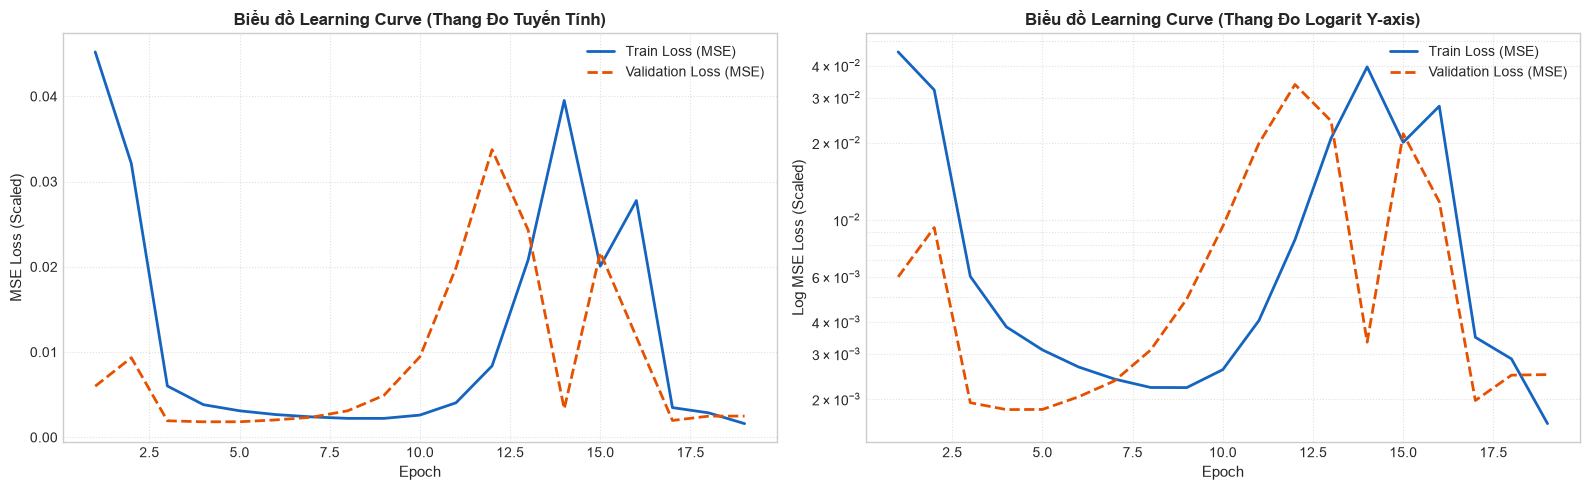

Loss khởi điểm (Epoch 1)      : Train Loss = 0.045207 | Val Loss = 0.005993
Epoch tốt nhất theo Validation: 4 | Train Loss = 0.003826 | Val Loss = 0.001820
Tỷ lệ giảm Loss của tập Train : 96.45%


In [15]:
# 14. Trực quan hóa đường cong hàm mất mát (Learning Curve)
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Thang đo tuyến tính
axes[0].plot(epochs_range, train_loss, label='Train Loss (MSE)', color='#1565C0', linewidth=2.0)
axes[0].plot(epochs_range, val_loss, label='Validation Loss (MSE)', color='#E65100', linewidth=2.0, linestyle='--')
axes[0].set_title("Biểu đồ Learning Curve (Thang Đo Tuyến Tính)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("MSE Loss (Scaled)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Thang đo Logarit (Semi-Log)
axes[1].plot(epochs_range, train_loss, label='Train Loss (MSE)', color='#1565C0', linewidth=2.0)
axes[1].plot(epochs_range, val_loss, label='Validation Loss (MSE)', color='#E65100', linewidth=2.0, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_title("Biểu đồ Learning Curve (Thang Đo Logarit Y-axis)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Log MSE Loss (Scaled)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, which="both", linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Loss khởi điểm (Epoch 1)      : Train Loss = {train_loss[0]:.6f} | Val Loss = {val_loss[0]:.6f}")
best_epoch = int(np.argmin(val_loss)) + 1
print(f"Epoch tốt nhất theo Validation: {best_epoch} | Train Loss = {train_loss[best_epoch-1]:.6f} | Val Loss = {val_loss[best_epoch-1]:.6f}")
print(f"Tỷ lệ giảm Loss của tập Train : {((train_loss[0] - train_loss[-1]) / train_loss[0]) * 100:.2f}%")


### Phân Tích Ý Nghĩa Đường Cong Mất Mát & Đánh Giá Overfitting:

#### 1. Mô hình học như thế nào qua các Epoch?
* Chạy **19 epoch**, chọn trọng số tại **epoch 4** theo validation. Train loss từ **0.045207** xuống **0.001605**; validation loss cuối **0.002493**, thấp nhất **0.001820**.
* EarlyStopping dừng sau 15 epoch không cải thiện kể từ epoch tốt nhất. Lần chạy có **19 epoch**, nên không diễn giải một giai đoạn “sau epoch 20”.
* Train loss giảm nhưng validation có dao động. Loss nhỏ nhất trên Train và Validation có thể nằm ở hai epoch khác nhau; code báo cả hai tại đúng epoch được chọn.

---

#### 2. Mô hình có bị Overfitting hay không?
* Validation không cải thiện so với epoch 4 trong phần còn lại; đây là lý do khôi phục trọng số sớm. Chưa đủ để tách ảnh hưởng overfitting, tối ưu không ổn định và khác biệt phân bố giữa các split.
* Không khẳng định hai đường loss luôn đồng quy hoặc hoàn toàn không overfit. Kết quả Test và baseline mới phản ánh giới hạn dự báo của cấu hình hiện tại.


---
<a id="section-15"></a>
## 15. Thực Hiện Dự Đoán (Prediction) & Khôi Phục Thang Đo Gốc (Inverse Transform)

### 15.1. Dự đoán trên tập Kiểm thử (Test Set) bằng `model.predict()`:
* Tập Test gồm **170 cửa sổ có chồng lấp**, với target từ **07/06/2017 đến 07/02/2018**. Không dùng các target này để cập nhật trọng số hoặc chọn epoch; đây không phải 170 mẫu độc lập thống kê.
* Chúng ta gọi phương thức `model.predict(X_test, batch_size=32)` để thu về mảng dự đoán $\hat{y}_{\text{scaled}} \in \mathbb{R}$.

---

### 15.2. Khôi phục về thang đo giá gốc USD (`inverse_transform`):
* Mọi tính toán gradient đều diễn ra trong không gian chuẩn hóa $[0, 1]$.
* Để đánh giá ý nghĩa kinh tế thực tế, chúng ta sử dụng `target_scaler.inverse_transform()` để đưa cả giá thực tế ($y$) và giá dự đoán ($\hat{y}$) trở về **đơn vị tiền tệ Dollar Mỹ (USD)**.

> **Thang đo**: Chỉ Train được MinMaxScaler đưa về [0,1]. Val/Test và đầu ra Linear/Dense có thể vượt khoảng này; `inverse_transform` vẫn áp dụng được. Các metrics dùng target gốc và dự báo đã đổi ngược về đơn vị gốc.


In [16]:
# 15. Thực hiện dự đoán trên Test Set và khôi phục giá trị USD gốc
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE)

# Áp dụng inverse_transform để chuyển đổi từ thang chuẩn hóa về USD (dự báo có thể nằm ngoài [0, 1])
y_test_actual = test_raw_data[sequence_length:, [3]].astype(np.float64)
y_test_predicted = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1).astype(np.float64))

# Trích xuất mốc thời gian tương ứng với từng phiên dự báo trong tập Test (sau seq_length=20)
test_target_dates = pd.to_datetime(test_dates[sequence_length:])

# Tạo bảng dữ liệu so sánh chi tiết Actual vs Predicted
df_pred_comparison = pd.DataFrame({
    'Ngày giao dịch': test_target_dates,
    'Giá thực tế (Actual USD)': y_test_actual.flatten(),
    'Giá Keras RNN dự đoán (USD)': y_test_predicted.flatten(),
    'Sai lệch tuyệt đối ($)': np.abs(y_test_predicted - y_test_actual).flatten(),
    'Sai số phần trăm (%)': (np.abs(y_test_predicted - y_test_actual) / y_test_actual).flatten() * 100
})

print("=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH ĐẦU TIÊN CỦA TẬP TEST ===")
display(df_pred_comparison.head(10).style.format({
    'Giá thực tế (Actual USD)': '${:.2f}',
    'Giá Keras RNN dự đoán (USD)': '${:.2f}',
    'Sai lệch tuyệt đối ($)': '${:.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))

print("\n=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH CUỐI CÙNG CỦA TẬP TEST ===")
display(df_pred_comparison.tail(10).style.format({
    'Giá thực tế (Actual USD)': '${:.2f}',
    'Giá Keras RNN dự đoán (USD)': '${:.2f}',
    'Sai lệch tuyệt đối ($)': '${:.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step 

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH ĐẦU TIÊN CỦA TẬP TEST ===


,Ngày giao dịch,Giá thực tế (Actual USD),Giá Keras RNN dự đoán (USD),Sai lệch tuyệt đối ($),Sai số phần trăm (%)
0,2017-06-07 00:00:00,$155.37,$145.63,$9.74,6.27%
1,2017-06-08 00:00:00,$154.99,$144.73,$10.26,6.62%
2,2017-06-09 00:00:00,$148.98,$145.48,$3.50,2.35%
3,2017-06-12 00:00:00,$145.42,$149.10,$3.68,2.53%
4,2017-06-13 00:00:00,$146.59,$140.93,$5.66,3.86%
5,2017-06-14 00:00:00,$145.16,$140.06,$5.10,3.51%
6,2017-06-15 00:00:00,$144.29,$141.36,$2.93,2.03%
7,2017-06-16 00:00:00,$142.27,$139.72,$2.55,1.79%
8,2017-06-19 00:00:00,$146.34,$141.12,$5.22,3.57%
9,2017-06-20 00:00:00,$145.01,$137.62,$7.39,5.10%



=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH CUỐI CÙNG CỦA TẬP TEST ===


,Ngày giao dịch,Giá thực tế (Actual USD),Giá Keras RNN dự đoán (USD),Sai lệch tuyệt đối ($),Sai số phần trăm (%)
160,2018-01-25 00:00:00,$171.11,$154.24,$16.87,9.86%
161,2018-01-26 00:00:00,$171.51,$151.64,$19.87,11.59%
162,2018-01-29 00:00:00,$167.96,$151.94,$16.02,9.54%
163,2018-01-30 00:00:00,$166.97,$152.52,$14.45,8.66%
164,2018-01-31 00:00:00,$167.43,$150.01,$17.42,10.40%
165,2018-02-01 00:00:00,$167.78,$150.17,$17.61,10.49%
166,2018-02-02 00:00:00,$160.50,$151.57,$8.93,5.56%
167,2018-02-05 00:00:00,$156.49,$153.43,$3.06,1.95%
168,2018-02-06 00:00:00,$163.03,$147.09,$15.94,9.78%
169,2018-02-07 00:00:00,$159.54,$148.41,$11.13,6.98%


---
<a id="section-16"></a>
## 16. Đo Lường Định Lượng Hiệu Năng (Evaluation Metrics: MAE, MSE, RMSE, MAPE)

Để đánh giá chất lượng dự báo một cách toàn diện và khoa học, chúng ta tính toán **bộ 4 chỉ số đo lường sai số chuẩn mực** trên tập Test dựa trên thang đo tiền tệ USD thực tế:

1. **MAE (Mean Absolute Error - Sai số tuyệt đối trung bình)**:
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
   * Đo lường độ lệch trung bình giữa giá dự báo và giá thực tế tính bằng USD. Rất trực quan và dễ hiểu đối với các nhà phân tích tài chính.

2. **MSE (Mean Squared Error - Sai số bình phương trung bình)**:
   $$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
   * Đo lường phương sai sai số, khuếch đại các sai lệch lớn.

3. **RMSE (Root Mean Squared Error - Căn bậc hai sai số bình phương trung bình)**:
   $$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2}$$
   * Có cùng đơn vị tính với giá cổ phiếu (USD). Vì phạt nặng các điểm sai số lớn nên $\text{RMSE} \ge \text{MAE}$; khoảng cách giữa RMSE và MAE càng nhỏ chứng tỏ mô hình dự báo càng đồng đều, ít xuất hiện ngoại lệ dị biệt.

4. **MAPE (Mean Absolute Percentage Error - Sai số phần trăm tuyệt đối trung bình)**:
   $$\text{MAPE} = \frac{100\%}{N} \sum_{i=1}^N \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$
   * Đo lường sai số tương đối theo tỷ lệ phần trăm so với giá trị thực tế, không phụ thuộc vào độ lớn của mức giá cổ phiếu. Trong giới phân tích tài chính, $\text{MAPE} < 5\%$ được coi là độ chính xác rất cao.


In [17]:
# 16. Tính toán 4 chỉ số định lượng MAE, MSE, RMSE, MAPE trên Test Set
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = y_test_actual.flatten()
y_pred = y_test_predicted.flatten()

mae_val  = mean_absolute_error(y_true, y_pred)
mse_val  = mean_squared_error(y_true, y_pred)
rmse_val = np.sqrt(mse_val)
mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("================================================================================")
print("=== BẢNG CHỈ SỐ ĐÁNH GIÁ ĐỊNH LƯỢNG MÔ HÌNH KERAS RNN TRÊN TẬP TEST ===")
print("================================================================================")
df_eval_metrics = pd.DataFrame({
    'Chỉ số đánh giá': [
        'MAE (Mean Absolute Error)',
        'MSE (Mean Squared Error)',
        'RMSE (Root Mean Squared Error)',
        'MAPE (Mean Absolute Percentage Error)'
    ],
    'Giá trị đạt được': [
        f"${mae_val:.2f} USD",
        f"{mse_val:.2f} USD²",
        f"${rmse_val:.2f} USD",
        f"{mape_val:.2f}%"
    ],
    'Công thức toán học': [
        '(1/N) * Σ |y - ŷ|',
        '(1/N) * Σ (y - ŷ)²',
        'sqrt(MSE)',
        '(100/N) * Σ |(y - ŷ) / y|'
    ],
    'Ý nghĩa thực tiễn': [
        'Sai lệch tuyệt đối trung bình giữa giá dự báo và giá thực tế',
        'Bình phương sai số trung bình (khuếch đại sai lệch lớn)',
        'Căn bậc hai của bình phương sai số trung bình, đơn vị USD',
        'Sai số tương đối phần trăm so với mức giá thực tế'
    ]
})
display(df_eval_metrics)
print("================================================================================")


# Baseline persistence: dự báo bước kế tiếp bằng giá trị quan sát gần nhất.
from sklearn.metrics import r2_score
baseline_pred = test_raw_data[sequence_length - 1:-1, 3].astype(np.float64)
actual_eval = y_test_actual.reshape(-1)
predicted_eval = y_test_predicted.reshape(-1)
assert len(baseline_pred) == len(actual_eval) == len(test_target_dates)
assert np.isfinite(predicted_eval).all()
baseline_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, baseline_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, baseline_pred))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - baseline_pred) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, baseline_pred)),
}
rnn_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, predicted_eval)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, predicted_eval))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - predicted_eval) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, predicted_eval)),
}
print("\n=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===")
display(pd.DataFrame([rnn_metrics, baseline_metrics], index=["Vanilla RNN", "Persistence (quan sát trước)"]).round(4))
print("Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.")



=== BẢNG CHỈ SỐ ĐÁNH GIÁ ĐỊNH LƯỢNG MÔ HÌNH KERAS RNN TRÊN TẬP TEST ===


,Chỉ số đánh giá,Giá trị đạt được,Công thức toán học,Ý nghĩa thực tiễn
0,MAE (Mean Absolute Error),$13.68 USD,(1/N) * Σ |y - ŷ|,Sai lệch tuyệt đối trung bình giữa giá dự báo ...
1,MSE (Mean Squared Error),228.32 USD²,(1/N) * Σ (y - ŷ)²,Bình phương sai số trung bình (khuếch đại sai ...
2,RMSE (Root Mean Squared Error),$15.11 USD,sqrt(MSE),"Căn bậc hai của bình phương sai số trung bình,..."
3,MAPE (Mean Absolute Percentage Error),8.27%,(100/N) * Σ |(y - ŷ) / y|,Sai số tương đối phần trăm so với mức giá thực tế



=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===


,MAE,RMSE,MAPE (%),R²
Vanilla RNN,13.6821,15.1103,8.2730,-1.1612
Persistence (quan sát trước),1.5034,2.1130,0.9368,0.9577


Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.


---
<a id="section-17"></a>
## 17. Trực Quan Hóa Kết Quả Dự Đoán (Actual vs Predicted & Residuals)

Để có cái nhìn toàn cảnh về khả năng dự báo của mô hình Keras RNN, chúng ta xây dựng biểu đồ trực quan hóa gồm 2 tầng:
1. **Tầng trên (Actual vs Predicted)**: Vẽ đường giá thực tế (Actual AAPL Close) song song cùng đường giá mô hình dự đoán (Predicted Close) theo đúng dòng thời gian từ tháng 05/2017 đến tháng 02/2018.
2. **Tầng dưới (Residuals Plot)**: Vẽ biểu đồ đường sai số phần dư $e_t = \hat{y}_t - y_t$ so với đường mốc $0$ USD nhằm kiểm tra độ ổn định và tính đối xứng của sai số dự báo.


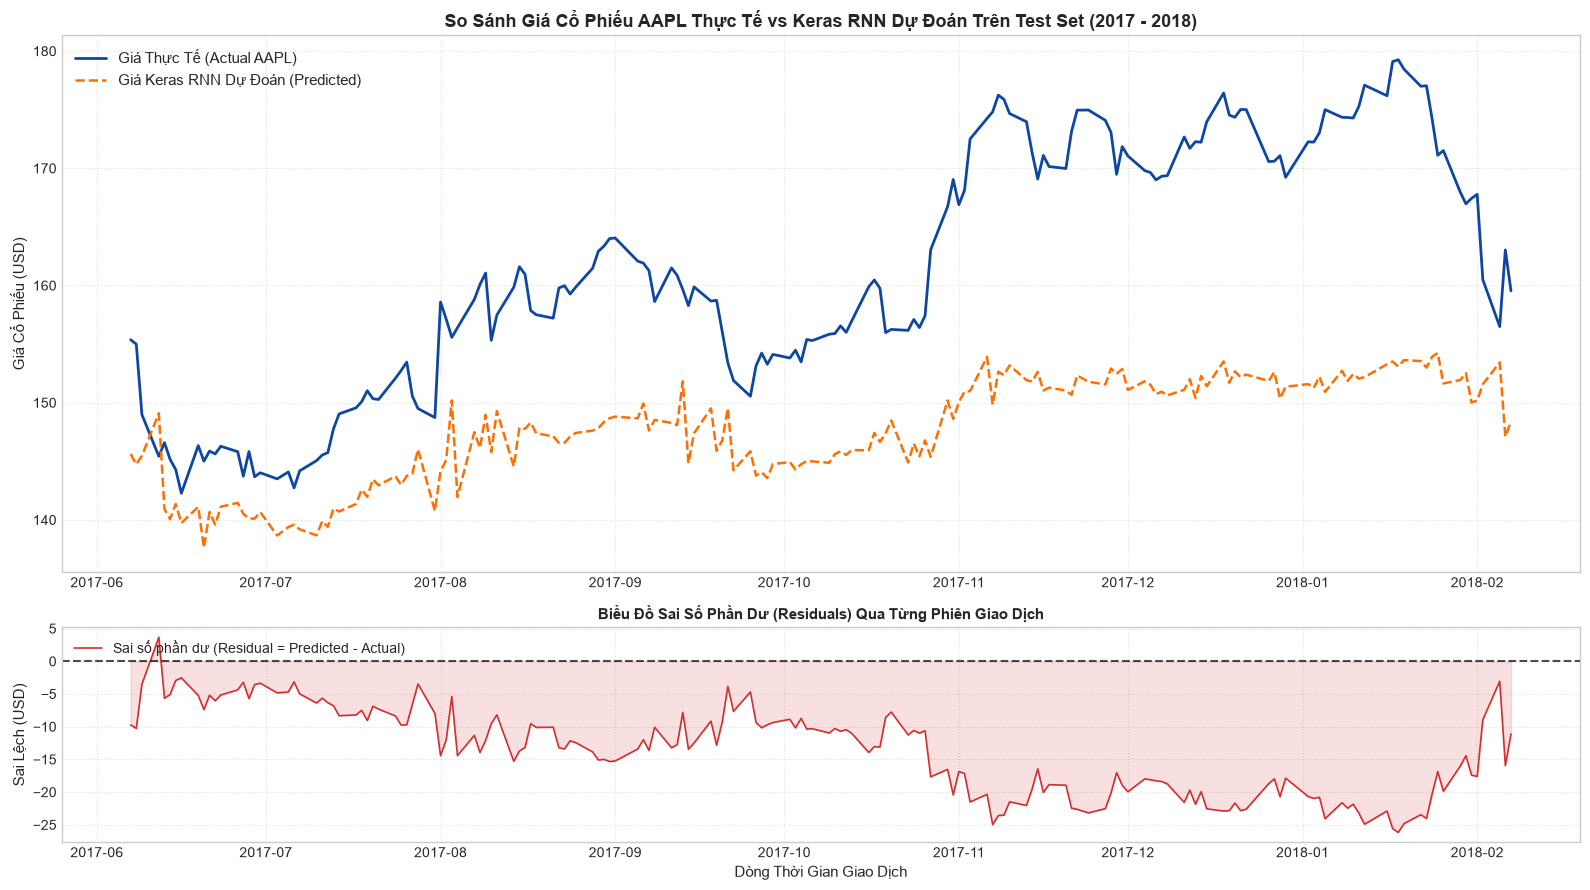

In [18]:
# 17. Trực quan hóa so sánh Actual vs Predicted và Biểu đồ Residuals
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [2.5, 1]})

# --- ĐỒ THỊ 1: ACTUAL VS PREDICTED ---
axes[0].plot(test_target_dates, y_true, label='Giá Thực Tế (Actual AAPL)', color='#0D47A1', linewidth=2.0)
axes[0].plot(test_target_dates, y_pred, label='Giá Keras RNN Dự Đoán (Predicted)', color='#FF6F00', linewidth=1.8, linestyle='--')
axes[0].set_title("So Sánh Giá Cổ Phiếu AAPL Thực Tế vs Keras RNN Dự Đoán Trên Test Set (2017 - 2018)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Giá Cổ Phiếu (USD)", fontsize=11)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- ĐỒ THỊ 2: BIỂU ĐỒ PHẦN DƯ (RESIDUALS) ---
residuals = (y_pred - y_true)
axes[1].plot(test_target_dates, residuals, label='Sai số phần dư (Residual = Predicted - Actual)', color='#D32F2F', linewidth=1.2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].fill_between(test_target_dates, residuals, 0, alpha=0.15, color='#D32F2F')
axes[1].set_title("Biểu Đồ Sai Số Phần Dư (Residuals) Qua Từng Phiên Giao Dịch", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Dòng Thời Gian Giao Dịch", fontsize=11)
axes[1].set_ylabel("Sai Lệch (USD)", fontsize=11)
axes[1].legend(fontsize=10, loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


---
<a id="section-18"></a>
## 18. Phân Tích Chuyên Sâu Kết Quả & Giới Hạn Của RNN Trong Tài Chính

### 1. Hiện tượng Trễ Pha 1 Bước (The 1-Step Phase Lag Phenomenon):
* **Kết quả đo được**: **MAE = $13.68**; **MSE = 228.32**; **RMSE = $15.11**; **MAPE = 8.27%**; **R² = -1.1612**.
* Baseline persistence trên **cùng 170 target**: MAE **$1.50**, RMSE **$2.11**, MAPE **0.94%**, R² **0.9577**.
* Bias trung bình **$-13.64** cho thấy dự báo thường thấp hơn thực tế. Biểu đồ chưa chứng minh độ trễ chính xác một phiên; mô hình hiện kém persistence rõ rệt.
* Các ngày có sai số lớn nhất, đơn vị USD:

| Ngày giao dịch | Thực tế | Dự đoán | Sai lệch tuyệt đối | Sai số (%) |
| :--- | ---: | ---: | ---: | ---: |
| `2018-01-18` | 179.26 | 153.09 | 26.17 | 14.60% |
| `2018-01-17` | 179.10 | 153.51 | 25.59 | 14.29% |
| `2017-11-07` | 174.81 | 149.83 | 24.98 | 14.29% |
| `2018-01-12` | 177.09 | 152.18 | 24.91 | 14.07% |
| `2018-01-19` | 178.46 | 153.63 | 24.83 | 13.91% |

---

### 2. Tỷ lệ Tín hiệu trên Nhiễu Thấp (Low Signal-to-Noise Ratio - SNR):
* Bài chưa ước lượng SNR hoặc phân rã nhiễu. Không dùng khái niệm này làm nguyên nhân đã được chứng minh cho sai số hiện tại.
* Đầu vào OHLCV không chứa tin tức hoặc các biến ngoại sinh; chưa kiểm chứng lợi ích của việc bổ sung các biến đó.

---

### 3. Giả thuyết Thị trường Hiệu quả (Efficient Market Hypothesis - EMH):
* EMH là bối cảnh lý thuyết, không phải kết luận kiểm định từ notebook này. Một lần chạy RNN kém không chứng minh thị trường không thể dự báo.
* Điều được dữ liệu xác nhận ở đây là cấu hình SimpleRNN hiện tại chưa vượt baseline giữ nguyên giá phiên trước trên cùng 170 target.

---

### 4. Giới hạn kiến trúc của Vanilla RNN:
* Mạng nén 20 phiên thành trạng thái 32 chiều, không có cơ chế cổng kiểu LSTM/GRU. Chưa đo gradient nên không quy mọi sai số cho vanishing gradient.
* Dense tuyến tính cho phép đầu ra ngoài [0,1]; tanh không đặt trần dự báo tại giá lớn nhất của Train.
* Chỉ dự báo một bước với dữ liệu lịch sử thực; chưa đánh giá độ dài cửa sổ khác, dự báo nhiều bước hoặc hiệu quả đầu tư.


---
<a id="section-19"></a>
## 19. PyTorch vs Keras Implementation

Dưới đây là bảng so sánh chi tiết về mặt kỹ thuật giữa hai nền tảng học sâu hàng đầu **PyTorch** (đã triển khai ở Notebook 01) và **TensorFlow / Keras** (triển khai ở Notebook 03) trên cùng một bài toán chuỗi thời gian cổ phiếu S&P 500.

> [!NOTE]
> Bảng này thuần túy mô tả sự khác biệt về mặt kỹ thuật, cú pháp, tư duy kiến trúc và cơ chế thực thi nội bộ; **tuyệt đối không nhằm mục đích xếp hạng hay kết luận framework nào tốt hơn framework nào**.

---

### Bảng So Sánh Kỹ Thuật Chi Tiết (7 Tiêu Chí Cốt Lõi):

| Tiêu chí so sánh | PyTorch Implementation (`01_RNN_PyTorch_Stock.ipynb`) | TensorFlow / Keras Implementation (`03_RNN_Keras_Stock.ipynb`) |
| :--- | :--- | :--- |
| **1. Định nghĩa Mô hình (Model Definition)** | • **Lập trình Hướng đối tượng (OOP)**: Định nghĩa lớp kế thừa từ `torch.nn.Module`.<br>• Phải viết tường minh hàm khởi tạo `__init__()` và phương thức lan truyền tiến `forward()`.<br>• Cần chú ý tham số `batch_first=True` khi khởi tạo `nn.RNN`.<br>• Trích xuất thủ công hidden state cuối: `rnn_out[:, -1, :]`. | • **Khai báo dạng khối (Declarative / Sequential)**: Sử dụng `tf.keras.Sequential` hoặc Functional API.<br>• Các tầng được xếp chồng tuần tự dạng danh sách khối ngắn gọn.<br>• Định nghĩa kích thước đầu vào bằng `keras.layers.Input(shape=(20, 5))`.<br>• Tự động trích xuất trạng thái cuối thông qua cờ `return_sequences=False`. |
| **2. Vòng lặp Huấn luyện (Training Loop)** | • **Thủ công và Tường minh (Explicit & Granular)**:<br>  1. `optimizer.zero_grad()`<br>  2. `preds = model(x)`<br>  3. `loss = criterion(preds, y)`<br>  4. `loss.backward()`<br>  5. `optimizer.step()`<br>• Người lập trình tự quản lý chuyển chế độ `model.train()` / `model.eval()` và khối `with torch.no_grad():` khi validation. | • **Đóng gói Cấp cao (Abstracted High-Level)**:<br>• Toàn bộ quy trình lặp epoch, gom mini-batch, tính loss, lan truyền ngược và đánh giá validation được đóng gói tự động trong phương thức duy nhất: `model.fit()`.<br>• Tự động chuyển đổi giữa chế độ training và evaluation.<br>• Dễ dàng gắn các `callbacks` (ví dụ `EarlyStopping`). |
| **3. Bộ Tối Ưu (Optimizer)** | • Khởi tạo `torch.optim.Adam(model.parameters(), lr=...)`.<br>• Phải truyền tường minh danh sách `model.parameters()`.<br>• Việc cập nhật trọng số diễn ra thủ công qua lệnh gọi `optimizer.step()` trong thân vòng lặp. | • Khởi tạo `keras.optimizers.Adam(learning_rate=...)`.<br>• Được cấu hình tập trung trong hàm `model.compile()`.<br>• Tự động liên kết và quản lý việc cập nhật gradient trên toàn bộ danh sách `trainable_variables` của mô hình. |
| **4. Hàm Mất Mát (Loss Function)** | • Khởi tạo `criterion = nn.MSELoss()`.<br>• Đóng vai trò như một Callable Object được gọi trực tiếp bên trong vòng lặp batch: `loss = criterion(preds, targets)`. | • Cấu hình trong hàm `model.compile(loss='mean_squared_error')` hoặc truyền instance `keras.losses.MeanSquaredError()`.<br>• Tự động tích hợp vào quá trình tính gradient và hiển thị log loss trên thanh tiến trình (progress bar). |
| **5. Cơ chế Dự đoán (Prediction)** | • Phải chuyển mô hình về `model.eval()`.<br>• Bao bọc bằng ngữ cảnh `with torch.no_grad():`.<br>• Duyệt thủ công qua `DataLoader`, gọi `model(batch_x)`, rồi chuyển tensor từ GPU/CPU về NumPy qua `.cpu().numpy()`. | • Gọi trực tiếp một phương thức duy nhất: `model.predict(X_test, batch_size=32)`.<br>• Tự động xử lý việc chia mini-batch, tắt gradient và trả về trực tiếp mảng `numpy.ndarray`. |
| **6. Đánh giá Định lượng (Evaluation)** | • Tự xây dựng hàm đánh giá lặp qua `DataLoader` để tính các chỉ số, hoặc lưu lại mảng dự đoán và dùng `sklearn.metrics`.<br>• Kiểm soát tuyệt đối từng phép toán số học. | • Cung cấp sẵn hàm `model.evaluate(X_test, y_test)` để nhanh chóng lấy loss và metrics đã khai báo khi compile.<br>• Đồng thời tương thích hoàn hảo với `sklearn.metrics` trên mảng trả về từ `model.predict()`. |
| **7. Số lượng Tham số (Weight Layout)** | • Tổng tham số: **$1,281$**.<br>• Do PyTorch tách riêng 2 vector bias: $b_{ih}$ và $b_{hh}$ ($32 + 32 = 64$ bias trong `nn.RNN`). | • Tổng tham số: **$1,249$**.<br>• Do Keras gộp bias của tầng hồi quy thành 1 vector duy nhất ($32$ bias trong `SimpleRNN`). |

---

### Tóm Tắt Đặc Trưng Kỹ Thuật:
* **PyTorch**: Đem lại cảm giác kiểm soát hoàn toàn từng dòng code (Control & Transparency). Rất thuận tiện khi muốn tùy biến các hàm mất mát phức tạp, can thiệp vào gradient, hoặc thử nghiệm các cấu trúc mạng thử nghiệm mới trong nghiên cứu học thuật.
* **Keras**: Đem lại năng suất phát triển cực nhanh (Productivity & Elegance). Cú pháp chuẩn hóa, dễ đọc, giảm thiểu tối đa các dòng code boilerplate (lặp đi lặp lại), cực kỳ mạnh mẽ trong việc triển khai công nghiệp và thử nghiệm nhanh các baseline chuẩn.

> **Điều kiện so sánh**: PyTorch chạy 100 epoch rồi khôi phục bản tốt nhất theo validation; Keras có EarlyStopping patience=15. Cùng seed không tạo cùng trọng số giữa framework. Chênh lệch metrics chưa thể quy cho PyTorch hay Keras.


---
<a id="section-20"></a>
## 20. Conclusion (Tổng Kết Cuối Cùng)

Notebook **`03_RNN_Keras_Stock.ipynb`** đã thực hiện quy trình dự báo giá cổ phiếu bằng **TensorFlow / Keras**; các kết luận dưới đây dựa trên output của lần chạy hiện tại:

### 1. Tổng kết các kết quả đạt được:
* **Tính toàn vẹn dữ liệu**: Đọc 1,259 phiên AAPL từ `dataset/all_stocks_5yr.csv`, dùng 5 đặc trưng OHLCV.
* **Quy trình tiền xử lý**:
  * Chia theo thời gian 70% / 15% / 15% trước khi tạo cửa sổ; MinMaxScaler chỉ fit Train.
  * Cửa sổ 20 phiên; Train / Validation / Test = **861 / 168 / 170** mẫu.
* **Xây dựng mô hình Keras Sequential**:
  * `Input(20, 5) -> SimpleRNN(32, tanh) -> Dense(1)`, tổng **1,249 tham số**.
  * Adam lr=0.001, MSE, batch 32; giữ vanilla RNN.
* **Huấn luyện & Kiểm soát Overfitting**:
  * Chạy **19 epoch**, EarlyStopping patience=15 khôi phục **epoch 4**, validation loss **0.001820**.
  * Validation có dao động và không cải thiện sau epoch tốt nhất; không khẳng định hoàn toàn không overfit.
* **Đánh giá đa chiều trên Test Set**:
  * Target dùng giá trị USD gốc; dự báo được inverse_transform về USD.
  * **MAE = $13.68**, **MSE = 228.32 USD²**, **RMSE = $15.11**, **MAPE = 8.27%**, **R² = -1.1612**.
  * Baseline persistence trên cùng Test: **MAE = $1.50**, **RMSE = $2.11**, **MAPE = 0.94%**. RNN hiện chưa vượt baseline.
* **Phân tích kết quả & So sánh kỹ thuật**:
  * Bias âm cho thấy dự báo thường thấp hơn thực tế; chưa kiểm định độ trễ đúng một bước hoặc nguyên nhân kinh tế.
  * PyTorch và Keras có cách khởi tạo và số lần cập nhật khác nhau; không quy chênh lệch metrics cho framework.
  * Đã đánh giá dự báo một bước trong notebook; **chưa deploy** và chưa đánh giá lợi nhuận giao dịch. Các cải tiến tiếp theo phải chọn bằng validation.

---
**KẾT THÚC NOTEBOOK 03 THÀNH CÔNG VÀ TRỌN VẸN!**
